<a href="https://colab.research.google.com/github/Fernandateireis/dotfiles/blob/master/plataformiza%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalar pacotes que não vêm no Colab por padrão
!pip install sentence-transformers umap-learn hdbscan \
             scikit-learn openpyxl plotly -q

In [ ]:
#Bibliotecas a serem trabalhadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from sentence_transformers import SentenceTransformer
from google.colab import files
import warnings, scipy.cluster.hierarchy as sch

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 130
print("✓ OK")

✓ OK


Abrir os microdados dos dois trimestres com o módulo plataformização (2022 T4 e 2024 T3), confirmar que a V4010 está lá.
As pnads estão no drive em parquet

In [ ]:
# Conectar o Google Drive (vai pedir autorização na primeira vez)
from google.colab import drive
drive.mount('/content/drive')

import os

# Pasta no Drive onde estão os arquivos — ajuste se usar outro nome
PASTA = '/content/drive/MyDrive/Colab Notebooks/pnad/'

ARQ = {
    2024: PASTA + 'pnadc_plataformizacao_2024T3.parquet',
    2022: PASTA + 'pnadc_plataformizacao_2022T4.parquet',
}
ARQ_COD = PASTA + 'Estrutura_Ocupacao_COD 1.xlsx'

# Conferência: cada arquivo existe?
for nome in list(ARQ.values()) + [ARQ_COD]:
    status = "✓" if os.path.exists(nome) else "✗ NÃO ENCONTRADO"
    print(f"{status}  {os.path.basename(nome)}")

Mounted at /content/drive
✓  pnadc_plataformizacao_2024T3.parquet
✓  pnadc_plataformizacao_2022T4.parquet
✓  Estrutura_Ocupacao_COD 1.xlsx


Etapa 2: ler os dados e deflacionar a renda

Célula 3: ler os parquets e dar uma primeira olhada

Esta célula lê os dois arquivos, que ficam num dicionário brutos com uma base por ano, e mostra o tamanho de cada um. Nada é filtrado ainda: é a base inteira, com todos os moradores entrevistados.

A leitura está certa: 479.778 pessoas em 2024, o mesmo número que apareceu no R, e 478.091 em 2022. A diferença no número de colunas (282 contra 255) é esperada, porque o módulo de 2024 tem perguntas a mais: motivo, número de aplicativos, trabalho secundário.
---




In [ ]:
# Ler os dois parquets num dicionário: {ano: tabela}
brutos = {ano: pd.read_parquet(arq) for ano, arq in ARQ.items()}

for ano, df in brutos.items():
    print(f"{ano}: {df.shape[0]:,} pessoas | {df.shape[1]} colunas")

# Espiar as primeiras linhas de 2024, só algumas colunas-chave
brutos[2024][['UF', 'V2009', 'V4010', 'VD4009', 'VD4016', 'SD14001', 'V1028']].head()

2024: 479,778 pessoas | 282 colunas
2022: 478,091 pessoas | 255 colunas


,UF,V2009,V4010,VD4009,VD4016,SD14001,V1028
0,11,21.0,None,None,NaN,None,222.260388
1,11,22.0,7231,01,4000.0,2,222.260388
2,11,46.0,9111,04,1412.0,2,160.455174
3,11,45.0,4412,07,2000.0,None,160.455174
4,11,16.0,None,None,NaN,None,160.455174


In [ ]:
# Tipo de cada coluna-chave: 'object' = texto, 'float64'/'int64' = número
chaves = ['UF', 'V2009', 'V2007', 'V4010', 'VD4002', 'VD4009', 'VD4012',
          'V4019', 'VD4016', 'V4039', 'SD14001', 'S140091', 'V1028']
brutos[2024][chaves].dtypes

,0
UF,object
V2009,float64
V2007,object
V4010,object
VD4002,object
VD4009,object
VD4012,object
V4019,object
VD4016,float64
V4039,float64


Calcular a taxa de plataformização por família da COD cruzada com seus grupos e níveis. Isso gera a primeira tabela empírica da camada e mostra onde a plataformização é fato observado e onde é apenas hipótese de cenário.

In [ ]:
import requests   # biblioteca para consultar a API do IBGE

# Número-índice do IPCA (SIDRA: tabela 1737, variável 2266) para um mês AAAAMM
def ipca_indice(periodo):
    url = f'https://apisidra.ibge.gov.br/values/t/1737/n1/all/v/2266/p/{periodo}'
    resposta = requests.get(url, timeout=30).json()
    return float(resposta[1]['V'])

indice_nov22 = ipca_indice('202211')
indice_ago24 = ipca_indice('202408')
FATOR_22_24 = indice_ago24 / indice_nov22

DEFLATOR = {2024: 1.0, 2022: FATOR_22_24}

print(f"IPCA nov/2022: {indice_nov22:,.2f}")
print(f"IPCA ago/2024: {indice_ago24:,.2f}")
print(f"Fator 2022 → 2024: {FATOR_22_24:.4f}  (inflação acumulada de {100*(FATOR_22_24-1):.1f}%)")

IPCA nov/2022: 6,434.20
IPCA ago/2024: 6,966.50
Fator 2022 → 2024: 1.0827  (inflação acumulada de 8.3%)


Preparar as bases

In [ ]:
REGIOES = {'1': 'Norte', '2': 'Nordeste', '3': 'Sudeste', '4': 'Sul', '5': 'Centro-Oeste'}

def prep_plat(df, ano):
    df = df.copy()

    # 1. Converter texto -> número (V4010 fica como texto)
    numericas = ['UF', 'V2009', 'V2007', 'V2010', 'VD3004', 'VD4002', 'VD4009', 'VD4012',
                 'V4019', 'VD4016', 'V4039', 'SD14001',
                 'S140091', 'S140092', 'S140093', 'S140094', 'V1028']
    for c in numericas:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    # 2. Universo IBGE: 14+, ocupados, sem setor público/militares, com resposta no módulo
    df = df[(df.V2009 >= 14) &
            (df.VD4002 == 1) &
            (~df.VD4009.isin([5, 6, 7])) &
            (df.SD14001.notna())].copy()

    # 3. Variáveis derivadas
    df['ano'] = ano
    df['cod'] = df.V4010.astype(str).str.zfill(4)
    df['sub_princ'] = df.cod.str[:2]
    df['grande_gr'] = df.cod.str[0]
    df['plat'] = df.SD14001 == 1
    df['app_taxi'] = df.S140091 == 1
    df['app_transp'] = df.S140092 == 1
    df['app_entrega'] = (df.S140093 == 1) & df.plat
    df['app_servicos'] = df.S140094 == 1
    df['informal'] = df.VD4009.isin([2, 4, 10]) | (df.VD4009.isin([8, 9]) & (df.V4019 == 2))
    df['contribui'] = df.VD4012 == 1
    df['mulher'] = df.V2007 == 2
    df['regiao'] = df.UF.astype(int).astype(str).str[0].map(REGIOES)

    # 4. Deflacionar (2022 -> preços de ago/2024) e renda-hora
    df['VD4016'] = df.VD4016 * DEFLATOR[ano]
    df['renda_hora'] = np.where(df.V4039 > 0, df.VD4016 / (df.V4039 * 4.33), np.nan)

    df['peso'] = df.V1028
    return df

bases = {ano: prep_plat(df, ano) for ano, df in brutos.items()}
b24, b22 = bases[2024], bases[2022]

for ano, df in bases.items():
    print(f"{ano}: {len(df):,} ocupados no universo | {df.plat.sum():,} plataformizados na amostra")

2024: 184,157 ocupados no universo | 2,743 plataformizados na amostra
2022: 178,163 ocupados no universo | 2,203 plataformizados na amostra


Validação


In [ ]:
def validar(df):
    p = df.peso
    return pd.Series({
        'ocupados (mil)':        p.sum() / 1e3,
        'plataformizados (mil)': p[df.plat].sum() / 1e3,
        'taxa (%)':              100 * p[df.plat].sum() / p.sum(),
        'táxi (mil)':            p[df.app_taxi].sum() / 1e3,
        'transporte (mil)':      p[df.app_transp].sum() / 1e3,
        'entrega (mil)':         p[df.app_entrega].sum() / 1e3,
        'serviços (mil)':        p[df.app_servicos].sum() / 1e3,
    })

pd.DataFrame({ano: validar(df) for ano, df in bases.items()})

,2024,2022
ocupados (mil),88512.377020,85608.300963
plataformizados (mil),1653.811761,1319.311958
taxa (%),1.868453,1.541103
táxi (mil),227.981492,200.877003
transporte (mil),877.880274,679.513386
entrega (mil),487.284887,445.866912
serviços (mil),293.642720,193.046251


A base está validada: 1.654 mil (1,87%) em 2024 e 1.319 mil (1,54%) em 2022, exatamente os números do IBGE. Táxi, transporte e serviços também batem.

A entrega saiu 487 mil, contra 485 mil do IBGE. A diferença de 2 mil (0,4%) vem da regra de contagem: a gente conta quem usa app de entrega e é plataformizado por qualquer critério, enquanto o IBGE aplica o filtro de atividade só para entrega. Não afeta nada.

A tabela já mostra um primeiro achado para os cenários, o crescimento por tipo de app entre 2022 e 2024:

Tipo	2022	2024	Variação
Serviços	193	294	+52%
Transporte	680	878	+29%
Táxi	201	228	+13%
Entrega	446	487	+9%

Quem mais cresce são os apps de serviços gerais e profissionais: diaristas, cuidadores, técnicos, freelancers. A entrega parece estar desacelerando. Isso reforça o cenário de "expansão" para cuidado e serviços profissionais, e esse segmento é justamente o que pode alcançar os níveis Técnico e Analista da sua classificação. (Lembre que 2022 é 4º trimestre e 2024 é 3º, então existe algum efeito sazonal.)

Etapa 4A: perfil sociodemográfico

Célula 8: criar as categorias

Os códigos do IBGE viram rótulos legíveis. Para comparar com o IBGE e com o relatório do Lanzara, usei os mesmos agrupamentos deles:

Sexo (V2007): 1 Homem, 2 Mulher.
Idade (V2009): 14–24, 25–39, 40–59, 60 ou mais.
Raça/cor (V2010): Branca, Preta, Parda e "Amarela/Indígena". As duas últimas ficam juntas porque têm poucos casos na amostra.
Instrução (VD3004), em quatro níveis como o IBGE divulga:
sem instrução ou fundamental incompleto (códigos 1–2);
fundamental completo ou médio incompleto (3–4);
médio completo ou superior incompleto (5–6);
superior completo (7).

In [ ]:
def categorias(df):
    df = df.copy()
    df['sexo'] = df.V2007.map({1: 'Homem', 2: 'Mulher'})
    df['faixa_idade'] = pd.cut(df.V2009, bins=[13, 24, 39, 59, 200],
                               labels=['14-24', '25-39', '40-59', '60+'])
    df['raca'] = df.V2010.map({1: 'Branca', 2: 'Preta', 4: 'Parda',
                               3: 'Amarela/Indígena', 5: 'Amarela/Indígena'})
    df['instrucao'] = df.VD3004.map({
        1: '1 Sem instr./fund. incompl.', 2: '1 Sem instr./fund. incompl.',
        3: '2 Fund. compl./médio incompl.', 4: '2 Fund. compl./médio incompl.',
        5: '3 Médio compl./sup. incompl.', 6: '3 Médio compl./sup. incompl.',
        7: '4 Superior completo'})
    return df

bases = {ano: categorias(df) for ano, df in bases.items()}
b24, b22 = bases[2024], bases[2022]

# Conferência: quantos ficaram sem categoria (deve ser ~0; raça "ignorada" = código 9)
for v in ['sexo', 'faixa_idade', 'raca', 'instrucao']:
    print(f"{v:12s} sem categoria: {b24[v].isna().sum()}")

sexo         sem categoria: 0
faixa_idade  sem categoria: 0
raca         sem categoria: 19
instrucao    sem categoria: 0


In [ ]:
def perfil(df, var):
    linhas = []
    for cat, g in df.groupby(var, observed=True):
        pl, npl = g[g.plat], g[~g.plat]
        linhas.append({
            'ano': df.ano.iloc[0], 'variavel': var, 'categoria': cat,
            'n plat (amostra)':    len(pl),
            'plat (mil)':          pl.peso.sum() / 1e3,
            '% entre plat':        100 * pl.peso.sum() / df.peso[df.plat].sum(),
            '% entre não plat':    100 * npl.peso.sum() / df.peso[~df.plat].sum(),
            'taxa plat %':         100 * pl.peso.sum() / g.peso.sum(),
            'renda plat (R$)':     np.average(pl.VD4016.dropna(), weights=pl.peso[pl.VD4016.notna()]) if len(pl) else np.nan,
            'renda não plat (R$)': np.average(npl.VD4016.dropna(), weights=npl.peso[npl.VD4016.notna()]),
        })
    return pd.DataFrame(linhas)

VARS_PERFIL = ['sexo', 'faixa_idade', 'raca', 'instrucao']

tab_perfil = pd.concat([perfil(df, v) for df in bases.values() for v in VARS_PERFIL],
                       ignore_index=True)

# Mostrar uma variável por vez, 2024 e 2022 lado a lado
for v in VARS_PERFIL:
    print(f"\n===== {v.upper()} =====")
    display(tab_perfil[tab_perfil.variavel == v]
            .pivot(index='categoria', columns='ano',
                   values=['% entre plat', '% entre não plat', 'taxa plat %',
                           'renda plat (R$)', 'renda não plat (R$)'])
            .round(1))


===== SEXO =====


% entre plat       % entre não plat       taxa plat %       \
ano               2022  2024             2022  2024        2022 2024   
categoria                                                              
Homem             83.9  83.9             58.5  58.3         2.2  2.7   
Mulher            16.1  16.1             41.5  41.7         0.6  0.7   

          renda plat (R$)         renda não plat (R$)          
ano                  2022    2024                2022    2024  
categoria                                                      
Homem              2929.2  3015.4              3027.5  3218.5  
Mulher             3118.1  2893.2              2241.0  2388.3


===== FAIXA_IDADE =====


% entre plat       % entre não plat       taxa plat %       \
ano               2022  2024             2022  2024        2022 2024   
categoria                                                              
14-24             10.2  11.1             15.8  15.3         1.0  1.4   
25-39             47.5  47.3             38.8  37.6         1.9  2.3   
40-59             36.4  36.2             37.9  38.9         1.5  1.7   
60+                6.0   5.3              7.5   8.2         1.2  1.2   

          renda plat (R$)         renda não plat (R$)          
ano                  2022    2024                2022    2024  
categoria                                                      
14-24              1971.5  2361.2              1603.2  1684.2  
25-39              2983.2  2859.6              2804.3  2966.4  
40-59              3178.9  3347.3              2976.4  3175.0  
60+                3118.2  3142.5              3080.2  3217.6


===== RACA =====


% entre plat       % entre não plat       taxa plat %       \
ano                      2022  2024             2022  2024        2022 2024   
categoria                                                                     
Amarela/Indígena          0.9   0.9              1.2   1.1         1.2  1.6   
Branca                   44.3  45.1             44.0  43.0         1.6  2.0   
Parda                    42.6  41.1             43.4  44.2         1.5  1.7   
Preta                    12.2  12.7             11.4  11.7         1.6  2.0   

                 renda plat (R$)         renda não plat (R$)          
ano                         2022    2024                2022    2024  
categoria                                                             
Amarela/Indígena          4112.7  2864.2              3598.2  3591.1  
Branca                    3428.8  3268.5              3474.4  3729.9  
Parda                     2574.6  2731.3              2080.1  2205.8  
Preta                     2512.4  2919.0              2015.8  2192.0


===== INSTRUCAO =====


% entre plat       % entre não plat        \
ano                                   2022  2024             2022  2024   
categoria                                                                 
1 Sem instr./fund. incompl.            7.8   9.3             23.2  21.7   
2 Fund. compl./médio incompl.         16.1  14.8             15.7  15.0   
3 Médio compl./sup. incompl.          61.4  59.3             43.1  44.4   
4 Superior completo                   14.7  16.6             18.0  18.9   

                              taxa plat %      renda plat (R$)          \
ano                                  2022 2024            2022    2024   
categoria                                                                
1 Sem instr./fund. incompl.           0.5  0.8          2336.3  2493.5   
2 Fund. compl./médio incompl.         1.6  1.8          2576.9  2875.7   
3 Médio compl./sup. incompl.          2.2  2.5          2716.6  2750.7   
4 Superior completo                   1.3  1.6          4736.6  4262.6   

                              renda não plat (R$)          
ano                                          2022    2024  
categoria                                                  
1 Sem instr./fund. incompl.                1632.2  1691.2  
2 Fund. compl./médio incompl.              1853.1  1918.7  
3 Médio compl./sup. incompl.               2287.2  2396.1  
4 Superior completo                        5770.7  6072.4

Célula 9: função de perfil

Para cada variável e cada ano, a função calcula três coisas:

Composição (% entre plat e % entre não plat): responde "quem são os plataformizados?". Por exemplo, que parcela deles é de mulheres.
Taxa de plataformização (taxa plat %): responde "em cada grupo, quantos são plataformizados?". Por exemplo, a porcentagem de mulheres ocupadas que trabalham por app.
Renda média de plataformizados e de não plataformizados, em reais de ago/2024. Em 2022 a renda já está deflacionada.

In [ ]:
def pct(df, cond, grupo):
    """% ponderado de 'cond' dentro do grupo (plataformizados ou não)."""
    g = df[grupo]
    return 100 * g.peso[cond[grupo]].sum() / g.peso.sum()

def renda_media(df, cond):
    g = df[cond & df.VD4016.notna()]
    return np.average(g.VD4016, weights=g.peso)

def tabela_perfil(df):
    P, N = df.plat, ~df.plat          # plataformizados / não plataformizados
    sup = df.instrucao == '4 Superior completo'
    linhas = {
        'Homens (%)':                      (pct(df, df.sexo == 'Homem', P),        pct(df, df.sexo == 'Homem', N)),
        '25–39 anos (%)':                  (pct(df, df.faixa_idade == '25-39', P), pct(df, df.faixa_idade == '25-39', N)),
        'Branca (%)':                      (pct(df, df.raca == 'Branca', P),       pct(df, df.raca == 'Branca', N)),
        'Preta (%)':                       (pct(df, df.raca == 'Preta', P),        pct(df, df.raca == 'Preta', N)),
        'Parda (%)':                       (pct(df, df.raca == 'Parda', P),        pct(df, df.raca == 'Parda', N)),
        'Sem instr./fund. incompl. (%)':   (pct(df, df.instrucao.str.startswith('1'), P), pct(df, df.instrucao.str.startswith('1'), N)),
        'Médio compl./sup. incompl. (%)':  (pct(df, df.instrucao.str.startswith('3'), P), pct(df, df.instrucao.str.startswith('3'), N)),
        'Superior completo (%)':           (pct(df, sup, P),                       pct(df, sup, N)),
        'Renda, superior completo (R$)':   (renda_media(df, P & sup),              renda_media(df, N & sup)),
    }
    return pd.DataFrame(linhas, index=['Plataformizados', 'Não plataformizados']).T

# Números de referência do IBGE (2024), citados no relatório Lanzara et al.
ibge_2024 = pd.Series({
    'Homens (%)': 83.9, '25–39 anos (%)': 47.3,
    'Branca (%)': 45.1, 'Preta (%)': 12.7, 'Parda (%)': 41.1,
    'Sem instr./fund. incompl. (%)': 9.3, 'Médio compl./sup. incompl. (%)': 59.3,
    'Superior completo (%)': 16.6, 'Renda, superior completo (R$)': 4263,
}, name='IBGE plat 2024')

t24 = tabela_perfil(b24).add_suffix(' 2024')
t22 = tabela_perfil(b22).add_suffix(' 2022')

validacao_perfil = pd.concat([t24, ibge_2024, t22], axis=1).round(1)
validacao_perfil

,Plataformizados 2024,Não plataformizados 2024,IBGE plat 2024,Plataformizados 2022,Não plataformizados 2022
Homens (%),83.9,58.3,83.9,83.9,58.5
25–39 anos (%),47.3,37.6,47.3,47.5,38.8
Branca (%),45.1,43.0,45.1,44.3,44.0
Preta (%),12.7,11.7,12.7,12.2,11.4
Parda (%),41.1,44.2,41.1,42.6,43.4
Sem instr./fund. incompl. (%),9.3,21.7,9.3,7.8,23.2
Médio compl./sup. incompl. (%),59.3,44.4,59.3,61.4,43.1
Superior completo (%),16.6,18.9,16.6,14.7,18.0
"Renda, superior completo (R$)",4262.6,6072.4,4263.0,4736.6,5770.7


A vantagem é grande (~50%) até o ensino médio incompleto, cai para ~15% no médio completo e vira perda no superior. E o padrão se acentuou entre 2022 e 2024 nas duas pontas.

Como interpretar. É a mesma lógica que o relatório mostra entre regiões, no Nordeste: a plataforma "compensa" onde a alternativa fora dela é pior. Para quem tem pouca escolaridade, a alternativa costuma ser o emprego informal mal pago, o trabalho doméstico ou o salário mínimo com carteira, e o app paga mais que isso. Para quem tem diploma, a alternativa é um emprego qualificado, e o app paga bem menos. É a "zona cinzenta" do Lanzara vista pela escolaridade.

Três cautelas antes de afirmar isso no texto:

Renda mensal não é renda por hora. Plataformizados trabalham ~45 h por semana contra ~39 h. Parte do prêmio é só trabalhar mais horas. Pelo IBGE, na média geral a vantagem mensal de +4% vira desvantagem de −8% por hora.
Os grupos comparados têm composições diferentes. Os plataformizados de baixa escolaridade são quase todos homens motoristas e motociclistas. Os não plataformizados do mesmo nível incluem muitas mulheres, trabalhadoras domésticas e trabalhadores rurais, com renda mais baixa. Parte do prêmio é efeito de sexo e de ocupação, não da plataforma.
A renda é bruta. Para conta própria, a VD4016 costuma vir sem descontar combustível e manutenção. O CEBRAP estima esses custos em ~R$ 740 por mês para entregadores e ~R$ 2.500 para motoristas.

In [ ]:
(tab_perfil[tab_perfil.variavel == 'instrucao']
 .pivot(index='categoria', columns='ano',
        values=['renda plat (R$)', 'renda não plat (R$)'])
 .round(0))

renda plat (R$)         renda não plat (R$)  \
ano                                      2022    2024                2022   
categoria                                                                   
1 Sem instr./fund. incompl.            2336.0  2493.0              1632.0   
2 Fund. compl./médio incompl.          2577.0  2876.0              1853.0   
3 Médio compl./sup. incompl.           2717.0  2751.0              2287.0   
4 Superior completo                    4737.0  4263.0              5771.0   

                                       
ano                              2024  
categoria                              
1 Sem instr./fund. incompl.    1691.0  
2 Fund. compl./médio incompl.  1919.0  
3 Médio compl./sup. incompl.   2396.0  
4 Superior completo            6072.0

Esse é o resultado principal. Comparando pessoas parecidas, o plataformizado típico (homem com ensino médio completo, que é a maioria) ganha 8% menos por hora que um homem com a mesma escolaridade fora das plataformas. Esse número bate com o −8,3% por hora que o IBGE divulga para o total. A vantagem real existe só para homens de baixa escolaridade, para quem as alternativas fora do app são piores.

O padrão também é estável entre os anos: −7,8% no médio completo e ~−33% no superior tanto em 2022 quanto em 2024. As variações maiores entre os anos estão justamente nos grupos com menos casos.

O que isso significa para o projeto
Uma frase para o texto: "Controlando jornada, sexo e escolaridade, a plataforma só oferece rendimento-hora superior para trabalhadores de baixa escolaridade; para a maioria (ensino médio completo), representa perda de cerca de 8% por hora, e para os diplomados, de cerca de 35%."
Para a projeção: a escolaridade vai subir até 2040, então cada vez menos trabalhadores estarão no grupo em que a plataforma "compensa". Pela lógica da renda, isso tende a frear a plataformização. O contrapeso seria o crescimento dos apps de serviços, que já foi o segmento que mais cresceu (+52%).

In [ ]:
def premio(df, var, medida='VD4016'):
    linhas = []
    for cat, g in df.groupby(var, observed=True):
        pl, npl = g[g.plat & g[medida].notna()], g[~g.plat & g[medida].notna()]
        r_pl = np.average(pl[medida], weights=pl.peso)
        r_npl = np.average(npl[medida], weights=npl.peso)
        linhas.append({'ano': df.ano.iloc[0], 'categoria': cat,
                       'plat': r_pl, 'não plat': r_npl,
                       'prêmio %': 100 * (r_pl / r_npl - 1),
                       'n plat': len(pl)})
    return pd.DataFrame(linhas)

comparacoes = {
    'Renda mensal – todos':      lambda df: premio(df, 'instrucao', 'VD4016'),
    'Renda-hora – todos':        lambda df: premio(df, 'instrucao', 'renda_hora'),
    'Renda-hora – só homens':    lambda df: premio(df[df.sexo == 'Homem'], 'instrucao', 'renda_hora'),
}

for titulo, f in comparacoes.items():
    t = pd.concat([f(df) for df in bases.values()])
    print(f"\n===== {titulo} =====")
    display(t.pivot(index='categoria', columns='ano', values=['prêmio %', 'n plat']).round(1))


===== Renda mensal – todos =====


prêmio %        n plat        
ano                               2022  2024    2022    2024
categoria                                                   
1 Sem instr./fund. incompl.       43.1  47.4   218.0   281.0
2 Fund. compl./médio incompl.     39.1  49.9   326.0   368.0
3 Médio compl./sup. incompl.      18.8  14.8  1320.0  1642.0
4 Superior completo              -17.9 -29.8   328.0   442.0


===== Renda-hora – todos =====


prêmio %        n plat        
ano                               2022  2024    2022    2024
categoria                                                   
1 Sem instr./fund. incompl.       17.5  46.5   218.0   281.0
2 Fund. compl./médio incompl.     14.8  25.7   326.0   368.0
3 Médio compl./sup. incompl.       6.5   4.0  1320.0  1642.0
4 Superior completo              -18.6 -24.3   328.0   442.0


===== Renda-hora – só homens =====


prêmio %        n plat        
ano                               2022  2024    2022    2024
categoria                                                   
1 Sem instr./fund. incompl.        7.0  32.5   191.0   251.0
2 Fund. compl./médio incompl.     11.1  19.1   287.0   334.0
3 Médio compl./sup. incompl.      -7.8  -7.8  1116.0  1394.0
4 Superior completo              -31.9 -34.5   223.0   305.0

O teste confirmou o resultado principal e corrigiu o número estranho.

O que mudou com a medida robusta. A razão de totais soma toda a renda e divide pelo total de horas do grupo, então um caso extremo pesa pouco. O grupo sem instrução em 2024 caiu de +46,5% para +27%. Isso confirma que o +46,5% era inflado por alguns casos com poucas horas declaradas. A partir de agora, esta é a medida a usar.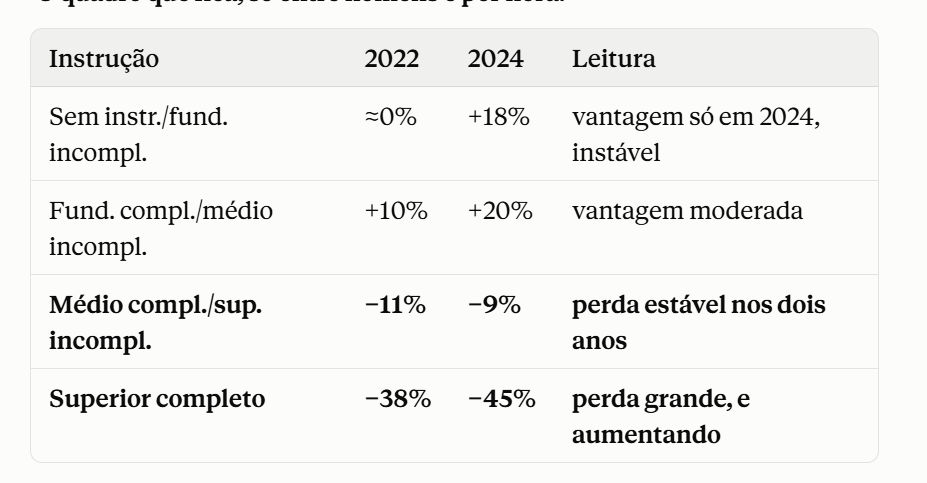

Três conclusões:

O resultado principal ficou mais forte, não mais fraco. O plataformizado típico (homem com ensino médio completo, ~60% do total) ganha cerca de 10% menos por hora que um homem com a mesma escolaridade fora das plataformas. O número é estável nos dois anos e próximo do −8,3% geral do IBGE.
A vantagem da baixa escolaridade é real, mas frágil. Em 2022 ela era praticamente zero entre os homens. Ela aparece em 2024, mas não dá para afirmar que é uma característica estável. Pode ser conjuntura, sazonalidade (4º contra 3º trimestre) ou variação amostral.
A penalidade dos diplomados é o achado mais robusto e o que mais cresce, de −38% para −45% por hora. Isso reforça a tese de sobreeducação.

Uma versão da frase para o texto: "Controlando jornada, sexo e escolaridade, o trabalho por plataforma não oferece vantagem de rendimento para a maioria dos trabalhadores: entre homens com ensino médio completo, o rendimento-hora é cerca de 10% inferior, e entre diplomados, 38% a 45% inferior. Apenas entre os de menor escolaridade observa-se vantagem, porém instável entre 2022 e 2024."

Continua valendo uma cautela: a renda declarada é bruta. Se descontarmos o custo do veículo, todos esses prêmios ficariam mais negativos.


In [ ]:
def premio_razao(df, var):
    linhas = []
    for cat, g in df.groupby(var, observed=True):
        g = g[g.VD4016.notna() & (g.V4039 > 0)]
        def rh(x):  # renda total / horas mensais totais (ponderado)
            return (x.VD4016 * x.peso).sum() / (x.V4039 * 4.33 * x.peso).sum()
        r_pl, r_npl = rh(g[g.plat]), rh(g[~g.plat])
        linhas.append({'ano': df.ano.iloc[0], 'categoria': cat,
                       'prêmio %': 100 * (r_pl / r_npl - 1)})
    return pd.DataFrame(linhas)

for titulo, filtro in {'todos': lambda d: d, 'só homens': lambda d: d[d.sexo == 'Homem']}.items():
    t = pd.concat([premio_razao(filtro(df), 'instrucao') for df in bases.values()])
    print(f"\n===== Renda-hora (razão de totais) – {titulo} =====")
    display(t.pivot(index='categoria', columns='ano', values='prêmio %').round(1))


===== Renda-hora (razão de totais) – todos =====


ano,2022,2024
categoria,,
1 Sem instr./fund. incompl.,12.5,27.0
2 Fund. compl./médio incompl.,14.8,27.1
3 Médio compl./sup. incompl.,3.6,2.1
4 Superior completo,-24.9,-34.9



===== Renda-hora (razão de totais) – só homens =====


ano,2022,2024
categoria,,
1 Sem instr./fund. incompl.,-0.3,18.1
2 Fund. compl./médio incompl.,9.7,19.7
3 Médio compl./sup. incompl.,-11.0,-9.3
4 Superior completo,-37.6,-45.0


ETapa 2: Etapa	O que é	Status
1–3	Dados, deflator, universo, validação	✅ feito
4A	Perfil (sexo, idade, raça, instrução) e prêmio de renda	✅ feito
4B	Indicadores por família COD, com erro-padrão	← agora
5	Tipo de app, região/UF e controle algorítmico	depois
6	Cruzamento com a sua classificação (grupo × nível)	quando o CSV existir
7	Cenários 2040: tendencial, regulação e expansão	final

A etapa 4B responde à pergunta central do seu projeto: em quais ocupações a plataformização é fato observado, e com que precisão? É ela que define onde a projeção usa taxa medida e onde usa hipótese de cenário.

In [ ]:
cod_raw = pd.read_excel(ARQ_COD, dtype=str)
cod_raw.columns = ['gg', 'sgp', 'sg', 'familia', 'denominacao']

cod_familias = (cod_raw.dropna(subset=['familia'])
                .assign(cod=lambda d: d.familia.str.strip().str.zfill(4),
                        nome_familia=lambda d: d.denominacao.str.strip())
                [['cod', 'nome_familia']])

cod_sub_princ = (cod_raw.dropna(subset=['sgp'])
                 .assign(sub_princ=lambda d: d.sgp.str.strip().str.zfill(2),
                         nome_sub_princ=lambda d: d.denominacao.str.strip().str.capitalize())
                 [['sub_princ', 'nome_sub_princ']])

print(f"{len(cod_familias)} famílias | {len(cod_sub_princ)} subgrupos principais")

434 famílias | 43 subgrupos principais


## Etapa 5: plataformização por âncora e nível

Célula 17: ler o crosswalk e juntar às bases

O cruzamento está perfeito: todos os plataformizados caíram numa âncora, nos dois anos. Os poucos ocupados sem âncora (5 em 2024 e 13 em 2022, de cerca de 180 mil) são o código 0000, "ocupação mal definida", o mesmo resíduo que o relatório já registrava. Não afetam nada.

In [ ]:
caminho_ancoras = '/content/drive/MyDrive/Colab Notebooks/familias_COD_ancoras_final.csv'
ancoras = pd.read_csv(caminho_ancoras, sep=';', dtype={'cod_familia': str})
ancoras['cod_familia'] = ancoras['cod_familia'].str.zfill(4)

for ano in bases:
    bases[ano] = (bases[ano]
                  .drop(columns=['ancora', 'nivel'], errors='ignore')   # evita duplicar se rodar 2x
                  .merge(ancoras[['cod_familia', 'ancora', 'nivel']],
                         left_on='cod', right_on='cod_familia', how='left'))
b24, b22 = bases[2024], bases[2022]

# Cobertura: quantos plataformizados ficaram sem âncora? (esperado: ~0, só código 0000)
for ano, df in bases.items():
    sem = df[df.ancora.isna()]
    print(f"{ano}: {len(sem)} ocupados sem âncora | {sem.plat.sum()} plataformizados sem âncora")

2024: 5 ocupados sem âncora | 0 plataformizados sem âncora
2022: 13 ocupados sem âncora | 0 plataformizados sem âncora


Função indicadores
taxa = 100 * pl.peso.sum() / g.peso.sum()
É a soma dos pesos dos plataformizados dividida pela soma dos pesos de todos os ocupados do grupo.
Calcula o erro-padrão com os 200 pesos replicados:

taxas_rep = 100 * pl[REPS].sum() / g[REPS].sum()   
ep = np.std(taxas_rep, ddof=1)                    
cv = 100 * ep / taxa   
Calcula a qualidade do trabalho, para plataformizados e não plataformizados separadamente:

renda por hora (pela razão de totais, a medida robusta que adotamos);
horas trabalhadas por semana;
percentual que contribui para a previdência, que é a sua definição de formalidade.

5. Atribui o selo de confiabilidade ("boa", "cautela", "não publicar" ou "sem casos"), a partir do CV e do número de casos.
O que ela devolve

Uma tabela com uma linha por grupo e estas colunas:

Coluna	Significado
n amostra, n plat	número de pessoas na amostra: total e plataformizadas
ocupados (mil), plat (mil)	os mesmos números expandidos para a população
taxa plat %, EP, CV %	a taxa e sua precisão
renda-hora plat / não plat	renda por hora, em R$ de ago/2024
horas plat / não plat	jornada semanal média
contrib plat % / não plat %	percentual que contribui para a previdência
confiab	o selo de confiabilidade
A função está funcionando. No total do Brasil, a taxa é 1,87% com erro-padrão de 0,05 ponto. O intervalo de confiança de 95% vai de cerca de 1,77% a 1,97%, e o CV de 2,8% dá o selo de confiabilidade "boa".

Agora rode as células 18, 19 e 20, nessa ordem:

18: plataformização por âncora, em 2024 e 2022;
19: âncora × nível, em 2024;
20: teste da aproximação (8321 ∪ 8322 ∪ 9621) × conta própria contra a SD14001.
1. Por que existe erro

A PNAD não entrevista todo mundo. Ela entrevista uma amostra, uns 180 mil ocupados neste módulo, e usa o peso V1028 para expandir o resultado para os 88,5 milhões de ocupados. Se o IBGE tivesse sorteado outros domicílios, a taxa teria saído um pouco diferente: 1,85%, 1,90% e assim por diante. O 1,87% é a melhor estimativa, mas não é um valor exato.

2. Erro-padrão (EP = 0,05)

O erro-padrão mede o quanto a estimativa oscilaria se a pesquisa fosse repetida com outras amostras.

É para isso que servem os 200 pesos replicados. O IBGE simula 200 amostras alternativas, e a função recalcula a taxa em cada uma. Na prática, as 200 taxas ficaram mais ou menos entre 1,78% e 1,96%. O desvio-padrão dessas 200 taxas, 0,05 ponto percentual, é o erro-padrão.

3. Intervalo de confiança (1,77% a 1,97%)

O intervalo pega a estimativa e soma e subtrai cerca de 2 erros-padrão:

1,87 ± 1,96 × 0,05 → de 1,77% a 1,97%

A leitura é: "com 95% de confiança, a taxa real de plataformização entre os ocupados está entre 1,77% e 1,97%". Na prática, isso significa que, se a taxa de 2022 (1,54%) estiver fora desse intervalo e o intervalo de 2022 também não encostar no de 2024, o aumento é estatisticamente significativo, e não fruto do acaso da amostra.

4. Coeficiente de variação (CV = 2,8%)

O erro-padrão sozinho não diz se o erro é grande ou pequeno, porque depende do tamanho do número. Um EP de 0,05 é pequeno para uma taxa de 1,87%, mas seria enorme para uma taxa de 0,10%. O CV resolve isso comparando os dois:

CV = EP ÷ estimativa = 0,05 ÷ 1,87 = 2,8%

Ou seja, o erro equivale a 2,8% do próprio valor estimado, o que é muito pouco. É a mesma régua que o IBGE usa para decidir o que divulga:

CV	Selo	O que fazer
até 15%	boa	pode publicar
15% a 30%	cautela	publicar com ressalva
acima de 30% (ou menos de 30 casos)	não publicar	não usar a taxa isolada
Por que isso importa agora

No total do Brasil há 2.743 plataformizados na amostra, então o número é preciso. Quando dividirmos por âncora × nível, alguns grupos vão ter só 5 ou 10 plataformizados, e aí o CV sobe muito. O selo mostra, linha por linha, onde a plataformização é um dado confiável e onde é só ruído amostral. É isso que define onde a projeção usa taxa observada e onde entra como hipótese de cenário.

In [ ]:
##Função dos indicadores
# Pesos replicados (200 colunas V1028001...V1028200) — para o erro-padrão
REPS = [c for c in b24.columns if c.startswith('V1028') and len(c) == 8]
for ano in bases:
    bases[ano][REPS] = bases[ano][REPS].apply(pd.to_numeric, errors='coerce')
b24, b22 = bases[2024], bases[2022]

def media_p(x, w):
    m = x.notna()
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

def renda_hora_razao(g):
    g = g[g.VD4016.notna() & (g.V4039 > 0)]
    return (g.VD4016 * g.peso).sum() / (g.V4039 * 4.33 * g.peso).sum() if len(g) else np.nan

def indicadores(df, chaves):
    linhas = []
    for k, g in df.groupby(chaves, observed=True):
        pl, npl = g[g.plat], g[~g.plat]
        taxa = 100 * pl.peso.sum() / g.peso.sum()

        # erro-padrão: recalcula a taxa com cada um dos 200 pesos replicados
        taxas_rep = 100 * pl[REPS].sum().to_numpy() / g[REPS].sum().to_numpy()
        ep = np.std(taxas_rep, ddof=1)
        cv = 100 * ep / taxa if taxa > 0 else np.nan

        linha = dict(zip(chaves, k if isinstance(k, tuple) else (k,)))
        linha.update({
            'n amostra': len(g), 'n plat': len(pl),
            'ocupados (mil)': g.peso.sum() / 1e3,
            'plat (mil)': pl.peso.sum() / 1e3,
            'taxa plat %': taxa, 'EP': ep, 'CV %': cv,
            'renda-hora plat': renda_hora_razao(pl), 'renda-hora não plat': renda_hora_razao(npl),
            'horas plat': media_p(pl.V4039, pl.peso), 'horas não plat': media_p(npl.V4039, npl.peso),
            'contrib plat %': 100 * media_p(pl.contribui.astype(float), pl.peso),
            'contrib não plat %': 100 * media_p(npl.contribui.astype(float), npl.peso),
        })
        linhas.append(linha)

    out = pd.DataFrame(linhas)
    out['confiab'] = np.select(
        [out['n plat'] == 0,
         (out['n plat'] < 30) | (out['CV %'] > 30),
         out['CV %'] > 15],
        ['sem casos', 'não publicar', 'cautela'], default='boa')
    return out.sort_values('plat (mil)', ascending=False).reset_index(drop=True)

# Teste no total Brasil (esperado 2024: taxa 1,87%, CV ~3%, "boa")
indicadores(b24.assign(total='Brasil'), ['total'])[['plat (mil)', 'taxa plat %', 'EP', 'CV %', 'confiab']]

,plat (mil),taxa plat %,EP,CV %,confiab
0,1653.811761,1.868453,0.05185,2.775045,boa


In [ ]:
cols = ['ano', 'ancora', 'n plat', 'plat (mil)', 'taxa plat %', 'CV %', 'confiab',
        'renda-hora plat', 'renda-hora não plat', 'contrib plat %', 'contrib não plat %']

tab_ancora_plat = pd.concat([indicadores(df, ['ano', 'ancora']) for df in bases.values()])
tab_ancora_plat[cols].sort_values(['ano', 'plat (mil)'], ascending=[False, False]).round(2)

NameError: name 'indicadores' is not defined

PLataformização por âncora

A tabela confirma, com dados, o motor de mudança que o seu relatório atribuiu às âncoras: a plataformização é um fenômeno de Transporte e Logística e, em menor escala, de Comércio, Serviços e Lazer.

1. Onde está a plataformização (2024)
Âncora	Plataformizados	Parcela do total	Taxa na âncora	Confiabilidade
Transporte e Logística	1.193 mil	72%	17,3%	boa
Comércio, Serviços e Lazer	304 mil	18%	1,0%	boa
Administração e Gestão	49 mil	3%	0,4%	cautela
Indústria, Produção e Infraestrutura	47 mil	3%	0,3%	boa
Todas as outras	~61 mil	4%	—	não publicar
Juntas, as duas âncoras somam 90% dos plataformizados.
Em Transporte e Logística, 1 em cada 6 trabalhadores já é plataformizado.
Nas demais âncoras, a plataformização é marginal: menos de 0,5% dos ocupados, ou amostra insuficiente.
2. A mudança entre 2022 e 2024 é real?

Aqui entra o erro-padrão que acabamos de ver. Comparo a diferença entre os anos com o erro combinado dos dois:

Transporte e Logística: 14,8% → 17,3% (+2,4 pontos). A diferença é cerca de 3,7 vezes o erro, então o aumento é estatisticamente significativo.
Comércio, Serviços e Lazer: 0,83% → 1,01% (+0,2 ponto). A diferença é cerca de 1,9 vez o erro, no limite da significância. Indica crescimento, mas com cautela.
Administração e Gestão (0,21% → 0,42%): dobrou, mas ainda com selo de cautela. É uma pista a acompanhar, não uma conclusão.
3. Dois perfis de plataformização muito diferentes

Os indicadores de qualidade separam as duas âncoras principais:

	Transporte e Logística	Comércio, Serviços e Lazer
Renda-hora, plat × não plat	R$ 13,15 × 14,65 (−10%)	R$ 21,03 × 13,83 (+52%)
Contribui para a previdência, plat × não plat	25% × 69%	66% × 60%
Em Transporte e Logística, a plataforma precariza: paga menos por hora e tem um terço da proteção previdenciária. É o motorista e o entregador, o retrato do relatório do Lanzara.
Em Comércio, Serviços e Lazer, a plataforma parece qualificar: paga mais por hora e tem proteção igual ou maior. É provavelmente o prestador de serviços com MEI que consegue clientes por app. Esse é o segmento que mais cresceu (+52% entre 2022 e 2024).

Isso tem uma consequência direta para os cenários: não dá para tratar a plataformização como um único choque. É melhor pensar em dois:

plataformização logística: volume alto, precarizante, alvo natural do cenário de regulação;
plataformização de serviços: volume ainda pequeno, crescendo rápido, alvo do cenário de expansão.

Com 484 casos na amostra, dá para abrir Comércio, Serviços e Lazer por família e ver quem são esses prestadores. Fazemos isso depois da célula 20.

In [ ]:
cols = ['ano', 'ancora', 'n plat', 'plat (mil)', 'taxa plat %', 'CV %', 'confiab',
        'renda-hora plat', 'renda-hora não plat', 'contrib plat %', 'contrib não plat %']

tab_ancora_plat = pd.concat([indicadores(df, ['ano', 'ancora']) for df in bases.values()])
tab_ancora_plat[cols].sort_values(['ano', 'plat (mil)'], ascending=[False, False]).round(2)

,ano,ancora,n plat,plat (mil),taxa plat %,CV %,confiab,renda-hora plat,renda-hora não plat,contrib plat %,contrib não plat %
0,2024,Transporte e Logística,2030,1193.06,17.28,2.64,boa,13.15,14.65,25.01,68.74
1,2024,"Comércio, Serviços e Lazer",484,303.84,1.01,6.77,boa,21.03,13.83,65.68,60.20
2,2024,Administração e Gestão,63,48.65,0.42,18.70,cautela,31.63,25.37,73.68,86.34
3,2024,"Indústria, Produção e Infraestrutura",69,47.34,0.27,14.72,boa,19.12,14.54,51.12,59.31
4,2024,Cuidados,24,22.30,0.28,31.27,não publicar,17.56,12.52,71.55,46.69
5,2024,Humanidades e Cultura,36,18.36,1.55,22.87,cautela,16.04,25.59,37.42,56.36
6,2024,Ciência e Inovação,16,8.98,0.51,34.09,não publicar,39.49,47.62,68.78,89.28
7,2024,Educação,7,5.64,0.46,56.13,não publicar,8.67,26.59,95.08,73.52
8,2024,Saúde,12,5.00,0.32,38.99,não publicar,24.81,42.80,39.01,79.02
9,2024,Agropecuária e Pesca,2,0.63,0.01,81.74,não publicar,11.96,11.42,0.00,34.39


## Ancora por nível

1. A plataformização é quase toda operacional
Nível	Plataformizados	Parcela
Básico/Operacional	~1.500 mil	91%
Especialista	~82 mil	5%
Direção	~33 mil	2%
Técnico	~37 mil	2%
Transporte e Logística é 100% Básico/Operacional: 1.192 dos 1.193 mil plataformizados da âncora, com uma taxa de 17,6%.
Comércio, Serviços e Lazer tem a maior parte no Básico (255 mil), mas com uma diferença importante: ali os plataformizados contribuem mais para a previdência que os não plataformizados (65% contra 59%). Mesmo no nível operacional, a plataforma de serviços não segue o padrão precarizante da logística. Provavelmente são MEIs de serviços pessoais.
2. Existe uma plataformização qualificada, pequena, mas com taxas relevantes

Fora do Básico, os números absolutos são pequenos, mas algumas taxas chamam atenção. Aqui dá para usar as linhas com selo "cautela":

Âncora × nível	Plat (mil)	Taxa	Contrib plat × não plat
Comércio, Serviços e Lazer – Direção	32	3,3%	73% × 84%
Humanidades e Cultura – Especialista	16	2,0%	31% × 56%
Administração e Gestão – Especialista	33	1,3%	79% × 80%
Direção em Comércio, Serviços e Lazer (3,3%) tem a maior taxa fora da logística. Provavelmente são donos de pequenos negócios, como restaurantes e lojas, que vendem pelos apps de entrega ou de serviços.
Especialistas em Humanidades e Cultura (2,0%) são provavelmente freelancers criativos: design, tradução, produção de conteúdo. É o único grupo qualificado em que a plataforma precariza: só 31% contribuem, contra 56% fora dela.
Especialistas em Administração e Gestão (1,3%) são provavelmente consultores e profissionais de finanças e marketing por app. Aqui a proteção é igual à de quem está fora da plataforma.

O restante (Cuidados, Saúde, Educação e Ciência e Inovação no nível Especialista) aparece com casos, mas sem amostra suficiente para afirmar nada.

O que isso significa para os cenários
O choque de plataformização se aplica, na prática, a Transporte e Logística × Básico (17,6%, precisão "boa") e a Comércio, Serviços e Lazer × Básico (0,9%).
O cenário de expansão tem agora uma base empírica. Já há plataformização mensurável nos níveis Direção e Especialista de três âncoras. A hipótese do cenário seria que esses nichos cresçam até 2040, principalmente com os apps de serviços, que cresceram 52% em dois anos.
A pergunta anterior está respondida em parte. A renda-hora maior de Comércio, Serviços e Lazer vem, em parte, da Direção (donos de negócio). Mas mesmo o Básico dessa âncora tem mais proteção que os não plataformizados.

In [ ]:
tab_an_niv = pd.concat([indicadores(df, ['ano', 'ancora', 'nivel']) for df in bases.values()])

(tab_an_niv[(tab_an_niv.ano == 2024) & (tab_an_niv['n plat'] > 0)]
 [['ancora', 'nivel', 'n plat', 'plat (mil)', 'taxa plat %', 'CV %', 'confiab',
   'contrib plat %', 'contrib não plat %']]
 .sort_values('plat (mil)', ascending=False).round(2))

,ancora,nivel,n plat,plat (mil),taxa plat %,CV %,confiab,contrib plat %,contrib não plat %
0,Transporte e Logística,Básico/Operacional,2029,1192.33,17.60,2.64,boa,24.96,68.26
1,"Comércio, Serviços e Lazer",Básico/Operacional,400,254.54,0.94,7.54,boa,65.25,59.10
2,"Indústria, Produção e Infraestrutura",Básico/Operacional,55,38.21,0.25,16.29,cautela,48.43,55.31
3,Administração e Gestão,Especialista,43,33.13,1.28,23.90,cautela,79.08,80.46
4,"Comércio, Serviços e Lazer",Direção,59,31.60,3.28,16.35,cautela,72.59,83.69
5,"Comércio, Serviços e Lazer",Técnico,24,17.53,0.93,31.89,não publicar,59.15,63.74
6,Humanidades e Cultura,Especialista,31,16.30,1.96,24.58,cautela,31.16,55.51
7,Cuidados,Especialista,12,13.57,1.27,42.23,não publicar,91.16,78.64
8,"Indústria, Produção e Infraestrutura",Técnico,14,9.14,0.47,29.33,não publicar,62.34,86.00
9,Ciência e Inovação,Especialista,16,8.98,0.56,34.16,não publicar,68.78,88.71


## Teste de aproximação

A regra funciona razoavelmente, e de forma estável. Mas ela mede outra coisa, e isso acaba sendo útil.

Como ler o resultado
	2022	2024
Plataformizados de verdade (SD14001)	1.319 mil	1.654 mil
Marcados pela regra	1.643 mil	1.922 mil
Cobertura	67%	68%
Precisão	54%	59%
Cobertura estável, em ~68%: a regra pega dois terços dos plataformizados. O terço que falta são sobretudo os apps de serviços, que estão em outras famílias (os ~300 mil de Comércio, Serviços e Lazer, mais Administração, Humanidades etc.).
Precisão de ~55–59%: pouco mais da metade dos motoristas, motociclistas e entregadores conta própria usa app. O resto é taxista de ponto, frete, motoboy de loja.
A regra superestima o total: marca 1.922 mil quando os plataformizados são 1.654 mil.
O detalhe importante: a precisão está subindo

Entre 2022 e 2024 a precisão foi de 54% para 59%. Isso significa que o grupo "motoristas, motociclistas e entregadores conta própria" cresceu pouco (+17%), mas dentro dele a parcela que usa app cresceu (+5 pontos). O crescimento da plataformização vem de duas fontes:

o grupo de trabalhadores candidatos aumenta;
dentro desse grupo, mais gente migra para os apps.

Por isso não dá para simplesmente aplicar um fator de correção fixo à série de 2014 a 2025. O fator mudou de 0,80 para 0,86 em dois anos, e antes de 2022 não sabemos quanto era. Em 2014, quando o Uber chegou ao Brasil, a precisão era perto de zero. Uma série histórica "reconstruída" com fator fixo inventaria plataformização onde ela não existia.

Como usar isso: a regra mede o grupo de risco

Em vez de estimar plataformizados, a regra mede o grupo que pode ser plataformizado. Isso encaixa bem no modelo de projeção:

Plataformizados(t) = Grupo de risco(t) × Penetração(t) + Plataformização de serviços(t)

Componente	De onde vem	O que já sabemos
Grupo de risco	a sua série 2014–2025, com a regra aplicada	tem série longa → dá para projetar como as outras âncoras
Penetração	a precisão: 54% em 2022, 59% em 2024	vira o parâmetro dos cenários (curva logística com teto)
Serviços	a SD14001 fora das famílias de app, ~32% do total	pequeno, crescendo rápido → cenário de expansão

Com isso, os três cenários ganham parâmetros concretos:

Tendencial: a penetração continua subindo em curva que desacelera (por exemplo, até 70–75% em 2040), e os serviços crescem moderadamente.
Regulação: a penetração se estabiliza ou cai, porque a regulação aumenta o custo de operar pelo app, e a contribuição previdenciária sobe.
Expansão: a penetração sobe e os serviços aceleram para os níveis Especialista e Direção.

In [ ]:
FAM_APP = ['8321', '8322', '9621']   # motociclistas, motoristas, mensageiros/entregadores

def testa_proxy(df):
    proxy = df.cod.isin(FAM_APP) & (df.VD4009 == 9)      # 9 = conta própria
    w = df.peso
    return pd.Series({
        'SD14001 (mil)': w[df.plat].sum() / 1e3,
        'proxy (mil)':   w[proxy].sum() / 1e3,
        'acerto (mil)':  w[proxy & df.plat].sum() / 1e3,
        'cobertura %':   100 * w[proxy & df.plat].sum() / w[df.plat].sum(),
        'precisão %':    100 * w[proxy & df.plat].sum() / w[proxy].sum(),
    })

pd.DataFrame({ano: testa_proxy(df) for ano, df in bases.items()}).round(1)

,2024,2022
SD14001 (mil),1653.8,1319.3
proxy (mil),1922.3,1642.8
acerto (mil),1124.6,885.4
cobertura %,68.0,67.1
precisão %,58.5,53.9


### A série histórica do grupo de risco

In [ ]:
print("VD4009 – valores mais frequentes:")
print(serie.VD4009.value_counts().head(12))

print("\nV4010 – exemplos de códigos:")
print(serie.V4010.dropna().astype(str).unique()[:10])

print("\nQuantos estão nas famílias de app:", serie.cod.isin(FAM_APP).sum())

VD4009 – valores mais frequentes:
VD4009
Empregado no setor privado com carteira de trabalho assinada    683466
Conta-própria                                                   593990
Empregado no setor privado sem carteira de trabalho assinada    278168
Militar e servidor estatutário                                  184868
Trabalhador doméstico sem carteira de trabalho assinada          99879
Empregador                                                       88746
Trabalhador familiar auxiliar                                    72709
Empregado no setor público sem carteira de trabalho assinada     71732
Trabalhador doméstico com carteira de trabalho assinada          36815
Empregado no setor público com carteira de trabalho assinada     27171
Name: count, dtype: int64

V4010 – exemplos de códigos:
['8322' '5153' '4214' '0000' '2320' '2151' '2421' '4110' '2411' '2634']

Quantos estão nas famílias de app: 55686


Essa tabela mostra, com dados, a história da plataformização no Brasil, e confirma uma hipótese bem forte.

O que a série mostra

O grupo de risco (motoristas, motociclistas e entregadores conta própria) quase triplicou em 11 anos: de 744 mil em 2014 para 2,06 milhões em 2025. E cada ocupação tem o seu momento de salto, que coincide com a chegada de um tipo de app:

Período	O que acontece	Leitura
2014–2015	estável, ~750 mil	antes dos apps: taxistas, motoboys, fretes
2016–2019	motoristas: 519 → 1.100 mil (+112%)	expansão do Uber e do 99
2020–2021	motociclistas: 324 → 476 mil (+47%), enquanto motoristas caem na pandemia	boom do delivery (iFood, Rappi)
2023–2025	as duas sobem de novo: motoristas 1.043 → 1.356; motociclistas 452 → 685	nova onda pós-pandemia

A família 9621 (mensageiros e entregadores) é irrelevante, sempre com menos de 20 mil. Os entregadores de app se declaram motociclistas (8321).

O achado principal: o segmento "sem app" ficou parado

Com os dados do módulo (célula 20), dá para separar o grupo de risco em quem usa e quem não usa app:

	2014	2022	2024
Grupo de risco total	744	1.643	1.922
Usa app (acerto)	~0	885	1.125
Não usa app	~744	757	797

O segmento sem app ficou praticamente igual ao tamanho do grupo inteiro em 2014, em torno de 750–800 mil. Ou seja: todo o crescimento do grupo de risco desde 2015 corresponde a trabalhadores de app. Os apps não converteram taxistas e motoboys já existentes. Eles criaram um contingente novo de cerca de 1,1 a 1,3 milhão de pessoas.

Isso permite reconstruir a série histórica de forma defensável:

Plataformizados no grupo de risco(t) ≈ Grupo de risco(t) − base pré-app (~750 mil)

Não é mais um fator fixo inventado. É uma hipótese testada em dois pontos (2022 e 2024), com uma diferença de cerca de 10–15% atribuível às bases diferentes (entrevista anual × trimestre do módulo).

In [ ]:
vd = serie.VD4009.astype(str).str.strip().str.lower()
serie['conta_propria'] = (vd.str.contains('conta') & vd.str.contains('pr')) | vd.isin(['9', '09', '9.0'])
serie['grupo_risco'] = serie.cod.isin(FAM_APP) & serie.conta_propria

print("Registros no grupo de risco:", serie.grupo_risco.sum())   # deve ser milhares

nomes = {'8321': '8321 Motociclistas', '8322': '8322 Motoristas',
         '9621': '9621 Mensageiros/entregadores'}

grupo_risco = (serie[serie.grupo_risco]
               .groupby(['Ano', 'cod'])['V1032'].sum()
               .unstack('cod')
               .rename(columns=nomes) / 1e3)
grupo_risco['Total (mil)'] = grupo_risco.sum(axis=1)
grupo_risco.round(0)

Registros no grupo de risco: 27510


cod,8321 Motociclistas,8322 Motoristas,9621 Mensageiros/entregadores,Total (mil)
Ano,,,,
2014,239.0,500.0,4.0,744.0
2015,244.0,519.0,2.0,766.0
2016,286.0,606.0,5.0,897.0
2017,283.0,701.0,4.0,988.0
2018,299.0,964.0,5.0,1268.0
2019,324.0,1100.0,4.0,1429.0
2020,387.0,963.0,17.0,1368.0
2021,476.0,1018.0,10.0,1504.0
2022,452.0,1043.0,11.0,1505.0


Base pré-app: 755 mil


,grupo de risco (mil),base pré-app (mil),plat. estimados (mil),penetração %,plat. observados – módulo (mil)
Ano,,,,,
2014,744.0,755.0,0.0,0.0,NaN
2015,766.0,755.0,11.0,1.0,NaN
2016,897.0,755.0,142.0,16.0,NaN
2017,988.0,755.0,234.0,24.0,NaN
2018,1268.0,755.0,513.0,40.0,NaN
2019,1429.0,755.0,674.0,47.0,NaN
2020,1368.0,755.0,613.0,45.0,NaN
2021,1504.0,755.0,750.0,50.0,NaN
2022,1505.0,755.0,751.0,50.0,885.0


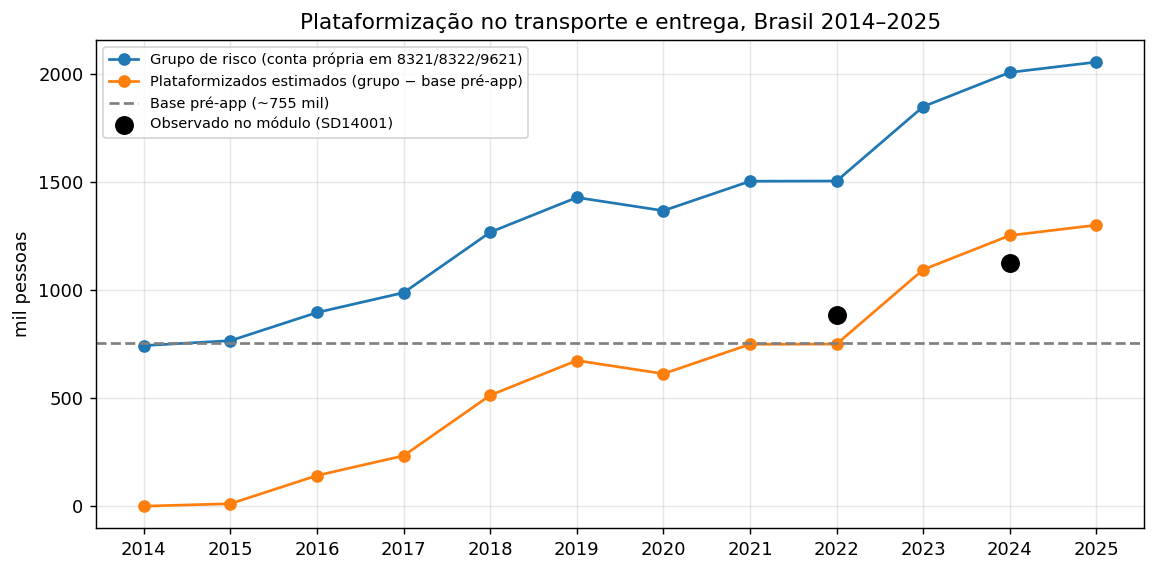

In [ ]:
import matplotlib.pyplot as plt

grupo_risco.index = grupo_risco.index.astype(int)      # <- NOVO: ano de texto para número

BASE_PRE_APP = grupo_risco.loc[[2014, 2015], 'Total (mil)'].mean()   # ~755 mil

reconstr = pd.DataFrame({
    'grupo de risco (mil)': grupo_risco['Total (mil)'],
    'base pré-app (mil)': BASE_PRE_APP,
})
reconstr['plat. estimados (mil)'] = (reconstr['grupo de risco (mil)'] - BASE_PRE_APP).clip(lower=0)
reconstr['penetração %'] = 100 * reconstr['plat. estimados (mil)'] / reconstr['grupo de risco (mil)']

# Pontos observados no módulo (acerto da célula 20: plataformizados dentro do grupo de risco)
observado = pd.Series({2022: 885.4, 2024: 1124.6}, name='plat. observados – módulo (mil)')
reconstr = reconstr.join(observado)

print(f"Base pré-app: {BASE_PRE_APP:.0f} mil")
display(reconstr.round(0))

# Gráfico
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(reconstr.index, reconstr['grupo de risco (mil)'], marker='o', label='Grupo de risco (conta própria em 8321/8322/9621)')
ax.plot(reconstr.index, reconstr['plat. estimados (mil)'], marker='o', label='Plataformizados estimados (grupo − base pré-app)')
ax.axhline(BASE_PRE_APP, ls='--', color='gray', label=f'Base pré-app (~{BASE_PRE_APP:.0f} mil)')
ax.scatter(observado.index, observado.values, s=90, color='black', zorder=5, label='Observado no módulo (SD14001)')
ax.set_title('Plataformização no transporte e entrega, Brasil 2014–2025')
ax.set_ylabel('mil pessoas'); ax.set_xticks(reconstr.index)
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

Ajustar uma curva logística e projetar até 2040
DEtalhe: 2020 e 2021 não utilizados

A curva logística tem três parâmetros:

K (teto): o número máximo de plataformizados que o mercado comporta;
r: a velocidade de crescimento;
t0: o ano em que a curva cresce mais rápido, ou seja, o ponto de inflexão.

A célula ajusta esses três parâmetros aos dados de 2014 a 2025 e projeta os três cenários. Cada cenário muda o teto K a partir de 2027:

Tendencial: o teto ajustado pelos dados;
Regulação: o teto cai 15%. Com contribuição obrigatória e mais custo por trabalhador, o mercado comporta menos gente;
Expansão: o teto sobe 20%, com novas modalidades e cidades menores entrando.

A mensagem principal: pelo ajuste, a plataformização no transporte e entrega está perto do teto. Em 2025 ela já está em cerca de 89% do máximo estimado (~1,46 milhão). No cenário tendencial, cresce pouco daqui em diante. A partir de agora, o que decide o futuro não é mais a difusão da tecnologia, mas fatores externos: regulação ou novas frentes de expansão. Isso dá um bom argumento para a camada 3.

Relacionando com a sua projeção Híbrido 2.0, em que Transporte e Logística vai de 7,47 para 7,75 milhões: hoje ~17% da âncora é plataformizada, o mesmo que o módulo mediu (17,6%). Em 2040, seriam ~19% no tendencial, ~16% na regulação e ~23% na expansão.

Três cautelas antes de usar

1. O teto depende muito dos últimos anos. A curva "achata" porque 2025 cresceu pouco sobre 2024 (+4%). Se 2025 tiver sido só um ano fraco, o teto real pode ser bem maior. Isso precisa ser testado (célula 25).

2. As quebras em 2027 e 2032 são artificiais. As linhas de regulação e expansão fazem "cotovelos" porque usei uma rampa linear que começa em 2027 e termina em 2032. Para o relatório, é melhor uma transição suave. Isso é um ajuste estético, e fazemos no final.

3. Os fatores 0,85 e 1,20 são hipóteses minhas. O desenho dos cenários está certo, mas a magnitude precisa de fundamento: a experiência da Espanha com a Ley Rider, o texto do PLP 12/2024 ou o diálogo com especialistas previsto no projeto.

Anos no ajuste: [2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025]
Teto K = 1,457 mil (EP 319) | velocidade r = 0.42 | inflexão t0 = 2020.4


,Tendencial,Regulação,Expansão
2025,1272.0,1272.0,1272.0
2030,1432.0,1303.0,1603.0
2035,1454.0,1236.0,1744.0
2040,1456.0,1238.0,1747.0


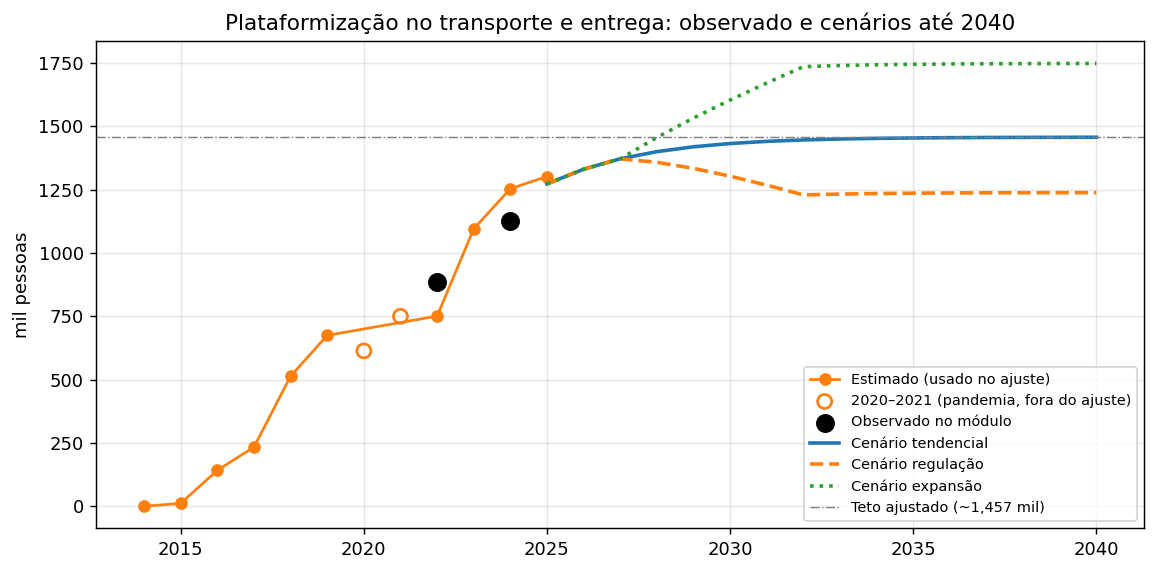

In [ ]:
from scipy.optimize import curve_fit

def logistica(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

# Anos usados no ajuste: tudo menos a pandemia
ANOS_EXCLUIDOS = [2020, 2021]
ajuste = reconstr.drop(index=ANOS_EXCLUIDOS)
anos = ajuste.index.values.astype(float)
y = ajuste['plat. estimados (mil)'].values
print(f"Anos no ajuste: {list(ajuste.index)}")

(K, r, t0), cov = curve_fit(logistica, anos, y, p0=[1500, 0.5, 2019],
                            bounds=([1000, 0.05, 2014], [5000, 3, 2035]))
ep_K = np.sqrt(np.diag(cov))[0]
print(f"Teto K = {K:,.0f} mil (EP {ep_K:,.0f}) | velocidade r = {r:.2f} | inflexão t0 = {t0:.1f}")

# Projeção 2025–2040 em três cenários (mudança no teto a partir de 2027, gradual até 2032)
anos_proj = np.arange(2025, 2041)
def rampa_k(ano, fator):
    x = np.clip((ano - 2027) / (2032 - 2027), 0, 1)
    return 1 + (fator - 1) * x

cenarios_plat = pd.DataFrame({
    'Tendencial': [logistica(a, K, r, t0) for a in anos_proj],
    'Regulação':  [logistica(a, K * rampa_k(a, 0.85), r, t0) for a in anos_proj],
    'Expansão':   [logistica(a, K * rampa_k(a, 1.20), r, t0) for a in anos_proj],
}, index=anos_proj)

display(cenarios_plat.loc[[2025, 2030, 2035, 2040]].round(0))

# Gráfico
todos = reconstr['plat. estimados (mil)']
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ajuste.index, y, 'o-', color='tab:orange', label='Estimado (usado no ajuste)')
ax.scatter(ANOS_EXCLUIDOS, todos.loc[ANOS_EXCLUIDOS], s=60, facecolors='none',
           edgecolors='tab:orange', lw=1.5, zorder=4, label='2020–2021 (pandemia, fora do ajuste)')
ax.scatter(observado.index, observado.values, s=90, color='black', zorder=5, label='Observado no módulo')
for nome, estilo in [('Tendencial', '-'), ('Regulação', '--'), ('Expansão', ':')]:
    ax.plot(anos_proj, cenarios_plat[nome], estilo, lw=2, label=f'Cenário {nome.lower()}')
ax.axhline(K, color='gray', lw=0.8, ls='-.', label=f'Teto ajustado (~{K:,.0f} mil)')
ax.set_title('Plataformização no transporte e entrega: observado e cenários até 2040')
ax.set_ylabel('mil pessoas'); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## Sensibilidade do teto


## O teto da logística não é robusto!!!

Como ler:

A linha "Sem 2020–21 e sem 2025" é a mais importante. Ela mostra quanto o teto depende daquele último ano.
A coluna EP de K é a incerteza do teto. Se ela for maior que uns 200 mil, o teto está pouco determinado pelos dados.


Teste	Teto K	Incerteza (EP)
Base (sem 2020–21)	1.457 mil	±319
Sem 2020–21 e sem 2025	1.187 mil	±201
Com todos os anos	1.559 mil	±329
Sem 2020–21, desde 2016	1.774 mil	±813
O teto varia de 1,19 a 1,77 milhão só mudando quais anos entram no ajuste. É uma diferença de 50%.
O teste sem 2025 é revelador. Ele dá um teto de 1,19 milhão, abaixo do que já foi observado em 2025 (~1,30 milhão). Ou seja: com os dados até 2024, a logística teria errado o ano seguinte.
Os erros-padrão são enormes, de ±200 a ±800 mil.

Conclusão: os dados ainda não mostram onde a curva vai achatar. O ajuste logístico "inventa" um teto a partir de um ou dois anos de desaceleração. Não é seguro usar esse teto como cenário tendencial.

In [ ]:
testes = {
    'Base (sem 2020–21)':        [2020, 2021],
    'Sem 2020–21 e sem 2025':    [2020, 2021, 2025],
    'Com todos os anos':         [],
    'Sem 2020–21, desde 2016':   [2014, 2015, 2020, 2021],
}

linhas = []
for nome, excluir in testes.items():
    d = reconstr.drop(index=excluir)
    try:
        (Kx, rx, t0x), covx = curve_fit(logistica, d.index.values.astype(float),
                                        d['plat. estimados (mil)'].values,
                                        p0=[1500, 0.5, 2019],
                                        bounds=([1000, 0.05, 2014], [5000, 3, 2035]))
        linhas.append({'teste': nome, 'teto K (mil)': Kx, 'EP de K': np.sqrt(covx[0, 0]),
                       'r': rx, 'inflexão': t0x, '2040 tendencial (mil)': logistica(2040, Kx, rx, t0x)})
    except RuntimeError:
        linhas.append({'teste': nome, 'teto K (mil)': np.nan})

pd.DataFrame(linhas).round(2)

,teste,teto K (mil),EP de K,r,inflexão,2040 tendencial (mil)
0,Base (sem 2020–21),1456.62,318.54,0.42,2020.43,1456.24
1,Sem 2020–21 e sem 2025,1186.84,200.80,0.57,2019.09,1186.83
2,Com todos os anos,1559.13,329.32,0.39,2020.98,1558.22
3,"Sem 2020–21, desde 2016",1773.70,812.93,0.32,2021.74,1768.49


Tribunal para a plataformização
Três competidores:

Congelamento: o último valor observado fica constante;
Tendência amortecida: a inclinação 2014–último ano, sem 2020–21, projetada com δ = 0,85, igual ao relatório;
Logística: a curva com teto.

Duas janelas de teste, como no relatório:

J1: estima com dados até 2019 e é julgada em 2022–2025;
J2: estima com dados até 2018 e é julgada em 2019 e 2022–2024.

A tendência amortecida venceu com folga, e nas duas janelas, o que atende à regra de robustez do seu relatório:

Método	J1	J2	Média
Tendência amortecida (δ = 0,85)	132	161	146
Logística	323	292	308
Congelamento	426	430	428

Como ler:

A tendência amortecida erra, em média, ~146 mil pessoas em anos que não viu. É cerca de 13% do nível da série, praticamente o mesmo tamanho do ruído da própria reconstrução (±12–15%). Não dá para exigir mais precisão do que isso.
A logística erra o dobro. Estimada com dados até 2018 ou 2019, ela "achou" um teto baixo cedo demais. É o mesmo problema que a sensibilidade mostrou.
O congelamento erra o triplo. A plataformização não parou de crescer.

A decisão metodológica: o cenário tendencial da plataformização usa tendência amortecida com δ = 0,85, o mesmo método e o mesmo parâmetro das seis âncoras que o usam no Híbrido 2.0. A logística fica descartada, pelo mesmo critério com que o relatório descartou o ML em Educação e em Transporte e Logística.

Um contraste interessante para o texto: no relatório, a âncora Transporte e Logística como um todo ficou no regime de congelamento (7,47 → 7,75 milhões). Mas a plataformização dentro dela segue uma tendência. Se as duas coisas valem ao mesmo tempo, a composição da âncora muda: os plataformizados ganham participação e o trabalho de transporte fora dos apps encolhe. É uma recomposição interna, parecida com a que o relatório descreveu em Cuidados.

In [ ]:
serie_plat = reconstr['plat. estimados (mil)'].drop(index=[2020, 2021])
DELTA = 0.85

def prev_congelamento(hist, anos_alvo):
    return pd.Series(hist.iloc[-1], index=anos_alvo)

def prev_tendencia(hist, anos_alvo, delta=DELTA):
    inclin = np.polyfit(hist.index.values, hist.values, 1)[0]   # mil pessoas por ano
    T = hist.index.max()
    return pd.Series([hist.iloc[-1] + inclin * sum(delta**k for k in range(1, a - T + 1))
                      for a in anos_alvo], index=anos_alvo)

def prev_logistica(hist, anos_alvo):
    try:
        p, _ = curve_fit(logistica, hist.index.values.astype(float), hist.values,
                         p0=[1500, 0.5, 2019], bounds=([hist.max(), 0.05, 2014], [5000, 3, 2035]))
        return pd.Series(logistica(np.array(anos_alvo, float), *p), index=anos_alvo)
    except RuntimeError:
        return pd.Series(np.nan, index=anos_alvo)

janelas = {'J1 (até 2019 → 2022–25)': (2019, [2022, 2023, 2024, 2025]),
           'J2 (até 2018 → 2019, 2022–24)': (2018, [2019, 2022, 2023, 2024])}
metodos = {'Congelamento': prev_congelamento, 'Tendência amortecida': prev_tendencia,
           'Logística': prev_logistica}

tribunal = {}
for nome_j, (ultimo, alvo) in janelas.items():
    hist = serie_plat[serie_plat.index <= ultimo]
    obs = serie_plat.loc[alvo]
    tribunal[nome_j] = {m: (f(hist, alvo) - obs).abs().mean() for m, f in metodos.items()}

tribunal = pd.DataFrame(tribunal)
tribunal['MAE médio'] = tribunal.mean(axis=1)
print("Erro absoluto médio (mil pessoas) — menor é melhor")
tribunal.round(0).sort_values('MAE médio')

Erro absoluto médio (mil pessoas) — menor é melhor


,J1 (até 2019 → 2022–25),"J2 (até 2018 → 2019, 2022–24)",MAE médio
Tendência amortecida,132.0,161.0,146.0
Logística,323.0,292.0,308.0
Congelamento,426.0,430.0,428.0


Projeção 2025–2040 com os três cenários

Como agora o método é a tendência amortecida, os cenários mudam a inclinação (a velocidade de crescimento) a partir de 2027, não um teto:

Tendencial: a inclinação estimada nos dados;
Regulação: a inclinação cai para 25% da tendencial, e a plataformização praticamente estabiliza;
Expansão: a inclinação sobe 50%.

A célula também lê o seu Híbrido 2.0 e calcula quanto da âncora Transporte e Logística seria plataformizada em cada cenário.

Pela tendência amortecida (δ = 0,85, o método que venceu o tribunal), a plataformização no transporte e entrega continua crescendo até 2040, cada vez mais devagar.

Cenário	2025	2030	2040	Parcela da âncora T&L em 2040
Tendencial	1,30 mi	1,69 mi	1,95 mi	25% (hoje 17%)
Regulação	1,30 mi	1,48 mi	1,54 mi	20%
Expansão	1,30 mi	1,84 mi	2,22 mi	29%

Os números bateram com o que eu esperava: cerca de 1,9 milhão no tendencial, 1,5 na regulação e 2,2 na expansão. Isso indica que a mecânica está correta.

A recomposição interna da âncora

No Híbrido 2.0, Transporte e Logística fica congelada (7,48 → 7,75 milhões). Se a plataformização cresce dentro de uma âncora que não cresce, o trabalho fora dos apps encolhe:

Cenário	T&L fora de app, 2025	2040	Variação
Tendencial	6,18 mi	5,81 mi	−6%
Regulação	6,18 mi	6,21 mi	estável
Expansão	6,18 mi	5,54 mi	−10%

É o mesmo tipo de achado do seu relatório para Cuidados: o total da âncora parece estável, mas a composição muda por dentro. Em Cuidados, o vínculo doméstico dá lugar ao cuidado profissional. Em T&L, o motorista empregado dá lugar ao motorista de app.

O que isso significa para a proteção social

Juntando a projeção com as taxas de contribuição que medimos em T&L em 2024 (25% entre plataformizados, 69% entre os demais), dá para estimar quantos trabalhadores da âncora ficam sem previdência. É uma ilustração, mantendo as taxas de hoje:

	2025	2040 tendencial	2040 regulação (com paridade de contribuição)
Sem previdência em T&L	~2,9 mi (39%)	~3,3 mi (42%)	~2,4 mi (31%)

Esta é a ponte com a etapa futura de políticas públicas que decidimos manter. A diferença entre os cenários é de quase 900 mil trabalhadores sem proteção previdenciária em 2040, só dentro de uma âncora. Isso mostra, com números, o que está em jogo na regulação das plataformas.

Inclinação estimada: 125 mil/ano | ponto de partida 2025: 1301 mil


,Tendencial,Regulação,Expansão,% da âncora T&L – Tendencial,% da âncora T&L – Regulação,% da âncora T&L – Expansão
2025,1301.4,1301.4,1301.4,17.4,17.4,17.4
2030,1694.3,1479.1,1837.8,22.2,19.4,24.1
2035,1868.6,1522.6,2099.3,24.2,19.7,27.2
2040,1946.0,1542.0,2215.3,25.1,19.9,28.6


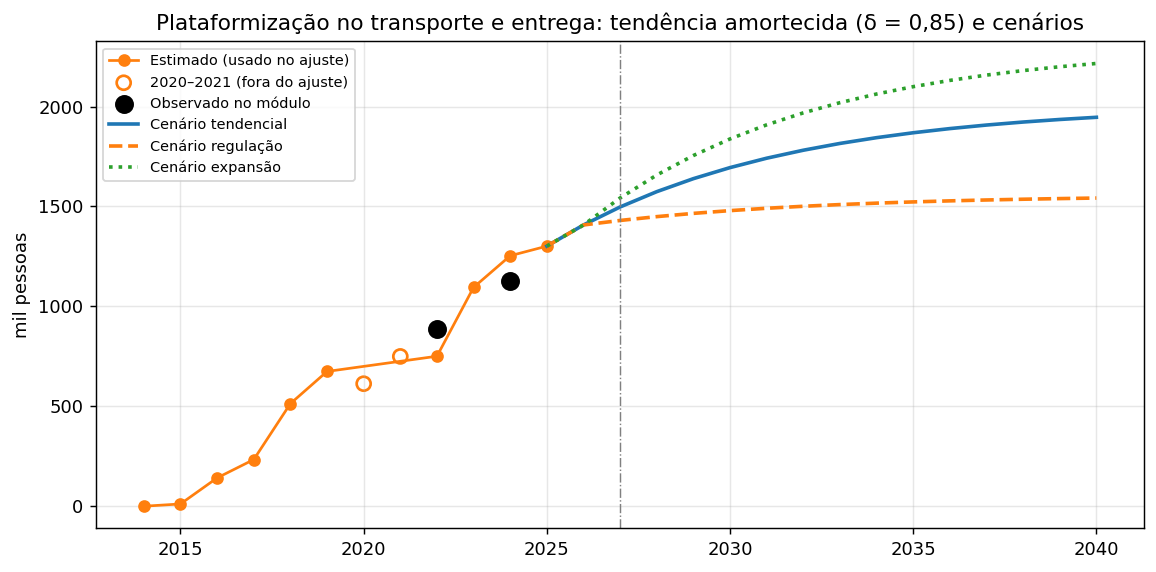

In [ ]:
hist = serie_plat                                      # 2014–2025 sem 2020–21
inclin = np.polyfit(hist.index.values, hist.values, 1)[0]
T, y_T = hist.index.max(), hist.iloc[-1]
print(f"Inclinação estimada: {inclin:.0f} mil/ano | ponto de partida {T}: {y_T:.0f} mil")

FATORES = {'Tendencial': 1.00, 'Regulação': 0.25, 'Expansão': 1.50}   # hipóteses a fundamentar
INICIO_CHOQUE = 2027

def projeta(fator):
    valores, acumulado = {T: y_T}, y_T
    for a in range(T + 1, 2041):
        mult = fator if a >= INICIO_CHOQUE else 1.0
        acumulado += inclin * DELTA**(a - T) * mult
        valores[a] = acumulado
    return pd.Series(valores)

cen = pd.DataFrame({nome: projeta(f) for nome, f in FATORES.items()})

# Participação na âncora Transporte e Logística (Híbrido 2.0, em milhões)
try:
    hib = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/camada2_hibrido_v2.parquet')
    hib.index = hib.index.astype(int)
    tl = hib['Transporte e Logística'] * 1000            # para mil pessoas
    for nome in FATORES:
        cen[f'% da âncora T&L – {nome}'] = 100 * cen[nome] / tl.reindex(cen.index)
except Exception as e:
    print("Não consegui ler o Híbrido 2.0:", e)

display(cen.loc[[2025, 2030, 2035, 2040]].round(1))

# Gráfico
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist.index, hist.values, 'o-', color='tab:orange', label='Estimado (usado no ajuste)')
ax.scatter([2020, 2021], reconstr.loc[[2020, 2021], 'plat. estimados (mil)'], s=60,
           facecolors='none', edgecolors='tab:orange', lw=1.5, label='2020–2021 (fora do ajuste)')
ax.scatter(observado.index, observado.values, s=90, color='black', zorder=5, label='Observado no módulo')
for nome, estilo in [('Tendencial', '-'), ('Regulação', '--'), ('Expansão', ':')]:
    ax.plot(cen.index, cen[nome], estilo, lw=2, label=f'Cenário {nome.lower()}')
ax.axvline(INICIO_CHOQUE, color='gray', lw=0.8, ls='-.')
ax.set_title('Plataformização no transporte e entrega: tendência amortecida (δ = 0,85) e cenários')
ax.set_ylabel('mil pessoas'); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## cenários revisados, com quantidade e proteção

Os cenários fundamentados deram um resultado mais claro e mais defensável que a versão anterior.

Passo 1 fechado: o que os cenários mostram
2040	Plataformizados	% da âncora T&L	Sem previdência em T&L
Tendencial	1,95 mi	25%	3,28 mi (42%)
Expansão	2,19 mi	28%	3,38 mi (44%)
Regulação leve (tipo PLP 152)	1,95 mi	25%	2,01 mi (26%)
Regulação forte (tipo Ley Rider)	1,81 mi	23%	2,04 mi (26%)

Em 2025, são 2,91 milhões sem previdência, ou 39% da âncora.

Três conclusões para o texto:

A quantidade varia pouco entre os cenários, de 1,81 a 2,19 milhões em 2040, ±10% em torno do tendencial. A plataformização continua crescendo em qualquer cenário.
A proteção varia muito. Entre o tendencial e a regulação leve, a diferença é de ~1,26 milhão de trabalhadores sem previdência em 2040, só em Transporte e Logística. Sem regulação, a desproteção na âncora sobe de 39% para 42%. Com ela, cai para 26%.
A regulação leve e a forte chegam praticamente ao mesmo resultado em proteção (26,0% e 26,3%). A forte ainda reduz um pouco o emprego nas plataformas. Pela evidência disponível, o modelo de contribuição obrigatória sem vínculo (PLP 152) alcança o ganho de proteção a um custo menor em emprego. É um resultado relevante para o debate de política.

Uma ressalva sobre a regulação forte: o modelo supõe que os 7% que saem das plataformas continuam trabalhando em Transporte e Logística fora dos apps, porque o total da âncora vem fixo do Híbrido 2.0. Na Espanha, parte foi para o desemprego. Então o custo da regulação forte, aqui, está subestimado.

Passo 2: o componente de serviços

São os plataformizados fora do grupo de risco: os apps de serviços gerais e profissionais, espalhados por Comércio, Serviços e Lazer, Administração, Humanidades e Indústria.

	2022	2024
Plataformizados (total)	1.319	1.654
No grupo de risco (acerto)	885	1.125
Fora do grupo de risco	434	529 (+22%)

A dificuldade: não dá para reconstruir uma série histórica como fizemos com o transporte. Esses trabalhadores estão espalhados por dezenas de famílias, e não existe uma "base pré-app" identificável. Temos só dois pontos, então não há como fazer o tribunal.

A proposta é tratar os serviços de forma mais simples e transparente:

Descrever onde estão: por âncora e nível, em 2022 e 2024 (célula 29).
Projetar com a mesma lógica amortecida, mas sobre a taxa de crescimento: crescimento de ~10% ao ano entre 2022 e 2024, amortecido com δ = 0,85. É uma hipótese declarada, sem validação fora da amostra.
Deixar a expansão para os níveis qualificados como cenário explícito, já que é ali que está a pergunta de política: a plataformização chega aos níveis Técnico e Especialista?

plataformizados (mil)                 % da âncora T&L        \
ano                              2025    2030    2040            2025  2030   
cenário                                                                       
Expansão                       1301.4  1760.7  2192.2            17.4  23.1   
Regulação forte                1301.4  1575.7  1809.8            17.4  20.6   
Regulação leve                 1301.4  1694.3  1946.0            17.4  22.2   
Tendencial                     1301.4  1694.3  1946.0            17.4  22.2   

                      sem previdência em T&L (mil)                  \
ano              2040                         2025    2030    2040   
cenário                                                              
Expansão         28.3                       2906.1  3158.3  3383.1   
Regulação forte  23.4                       2906.1  2053.2  2039.7   
Regulação leve   25.1                       2906.1  2028.0  2010.7   
Tendencial       25.1                       2906.1  3129.2  3275.5   

                % sem previdência              
ano                          2025  2030  2040  
cenário                                        
Expansão                     38.9  41.4  43.7  
Regulação forte              38.9  26.9  26.3  
Regulação leve               38.9  26.6  26.0  
Tendencial                   38.9  41.0  42.3

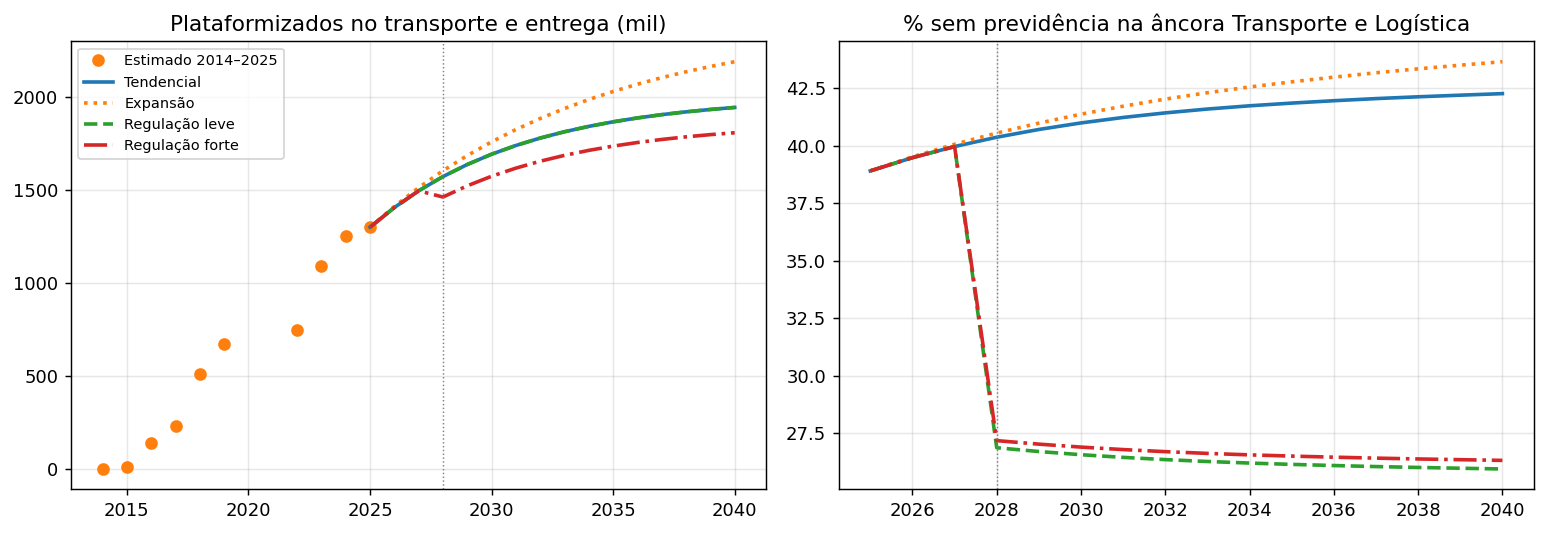

In [ ]:
ANO_REG = 2028          # hipótese: implementação da regulação
CONTRIB_REG = 90        # hipótese: % de plataformizados contribuindo com retenção na fonte
CONTRIB_PLAT_HOJE, CONTRIB_NPLAT = 25.0, 68.7     # T&L 2024 (célula 18)
QUEDA_LEY_RIDER = 0.07                            # Dolado, Jáñez & Wellschmied (2025)

def projeta_delta(delta, choque_nivel=0.0):
    valores, acum = {T: y_T}, y_T
    for a in range(T + 1, 2041):
        acum += inclin * delta**(a - T)
        valores[a] = acum * (1 - choque_nivel if a >= ANO_REG else 1)
    return pd.Series(valores)

cen2 = pd.DataFrame({
    'Tendencial':      projeta_delta(0.85),
    'Expansão':        projeta_delta(0.90),
    'Regulação leve':  projeta_delta(0.85),
    'Regulação forte': projeta_delta(0.85, choque_nivel=QUEDA_LEY_RIDER),
})
contrib = {'Tendencial': lambda a: CONTRIB_PLAT_HOJE, 'Expansão': lambda a: CONTRIB_PLAT_HOJE,
           'Regulação leve':  lambda a: CONTRIB_REG if a >= ANO_REG else CONTRIB_PLAT_HOJE,
           'Regulação forte': lambda a: CONTRIB_REG if a >= ANO_REG else CONTRIB_PLAT_HOJE}

tl = hib['Transporte e Logística'].reindex(cen2.index) * 1000     # âncora T&L, Híbrido 2.0 (mil)

resumo = []
for nome in cen2:
    for a in [2025, 2030, 2040]:
        plat = cen2.loc[a, nome]
        nplat = tl.loc[a] - plat
        sem_prev = plat * (1 - contrib[nome](a) / 100) + nplat * (1 - CONTRIB_NPLAT / 100)
        resumo.append({'cenário': nome, 'ano': a, 'plataformizados (mil)': plat,
                       '% da âncora T&L': 100 * plat / tl.loc[a],
                       'sem previdência em T&L (mil)': sem_prev,
                       '% sem previdência': 100 * sem_prev / tl.loc[a]})
resumo = pd.DataFrame(resumo)
display(resumo.pivot(index='cenário', columns='ano').round(1))

# Gráfico: quantidade e proteção lado a lado
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
estilos = {'Tendencial': '-', 'Expansão': ':', 'Regulação leve': '--', 'Regulação forte': '-.'}
a1.plot(hist.index, hist.values, 'o', color='tab:orange', label='Estimado 2014–2025')
for nome, ls in estilos.items():
    a1.plot(cen2.index, cen2[nome], ls, lw=2, label=nome)
    sp = [cen2.loc[a, nome] * (1 - contrib[nome](a)/100) + (tl.loc[a] - cen2.loc[a, nome]) * (1 - CONTRIB_NPLAT/100)
          for a in cen2.index]
    a2.plot(cen2.index, 100 * np.array(sp) / tl.values, ls, lw=2, label=nome)
a1.set_title('Plataformizados no transporte e entrega (mil)'); a1.grid(alpha=.3); a1.legend(fontsize=8)
a2.set_title('% sem previdência na âncora Transporte e Logística'); a2.grid(alpha=.3)
for ax in (a1, a2): ax.axvline(ANO_REG, color='gray', lw=0.8, ls=':')
plt.tight_layout(); plt.show()

ONde está a plataformização fora do transporte

A tabela mostra algo que não aparecia no total: fora do transporte, os níveis qualificados estão crescendo muito mais rápido que o Básico.

O que a tabela mostra

Agrupando as linhas por tipo de nível (a soma fica um pouco abaixo do total porque a tabela mostra só as 15 maiores linhas):

Componente de serviços	2022	2024	Variação
Básico/Operacional (CSL, T&L não conta própria, Indústria, Cuidados, Adm)	~331 mil	~375 mil	+13%
Qualificados (Direção + Técnico + Especialista)	~95 mil	~148 mil	+56%

O Básico cresce no ritmo do total, mas os níveis qualificados crescem quatro vezes mais rápido. Os destaques:

Administração e Gestão, Especialista: 10 → 33 mil, triplicou. São consultores, analistas e profissionais de marketing e finanças por app.
Humanidades e Cultura, Especialista: 6 → 16 mil, 2,5 vezes. Freelancers criativos.
Cuidados, Especialista: 4 → 14 mil, 3 vezes. Provavelmente psicólogos e terapeutas em plataformas de atendimento online.
Comércio, Serviços e Lazer, Direção e Técnico: crescimento moderado, de +16% e +17%.

É o primeiro sinal empírico de que a plataformização está saindo do trabalho operacional e chegando ao trabalho qualificado, o fenômeno que o cenário de expansão supunha.

Cautelas importantes:

A amostra é pequena. Administração e Gestão × Especialista tem só 22 e 43 casos. Cada linha isolada tem CV alto; o que é robusto é o padrão agregado, com quase todos os grupos qualificados crescendo ao mesmo tempo.
Na linha Transporte e Logística × Básico (fora do grupo de risco), os 81 → 68 mil são plataformizados que não são conta própria, como empregados de empresas de logística que operam por app. A queda pode ser só ruído amostral.

In [ ]:
def fora_do_grupo(df):
    no_grupo = df.cod.isin(FAM_APP) & (df.VD4009 == 9)
    return df.assign(plat_servicos=df.plat & ~no_grupo)

comp_serv = []
for ano, df in bases.items():
    d = fora_do_grupo(df)
    g = (d[d.plat_servicos].groupby(['ancora', 'nivel'], observed=True)['peso'].sum() / 1e3)
    n = d[d.plat_servicos].groupby(['ancora', 'nivel'], observed=True).size()
    comp_serv.append(pd.DataFrame({'ano': ano, 'plat serviços (mil)': g, 'n amostra': n}))
comp_serv = pd.concat(comp_serv).reset_index()

total_serv = comp_serv.groupby('ano')['plat serviços (mil)'].sum()
print("Total fora do grupo de risco (mil):", total_serv.round(0).to_dict())

(comp_serv.pivot_table(index=['ancora', 'nivel'], columns='ano',
                       values=['plat serviços (mil)', 'n amostra'], fill_value=0)
 .sort_values(('plat serviços (mil)', 2024), ascending=False)
 .round(1).head(15))

Total fora do grupo de risco (mil): {2022: 434.0, 2024: 529.0}


n amostra         \
ano                                                          2022   2024   
ancora                               nivel                                 
Comércio, Serviços e Lazer           Básico/Operacional     345.0  400.0   
Transporte e Logística               Básico/Operacional     101.0  107.0   
Indústria, Produção e Infraestrutura Básico/Operacional      59.0   55.0   
Administração e Gestão               Especialista            22.0   43.0   
Comércio, Serviços e Lazer           Direção                 51.0   59.0   
                                     Técnico                 20.0   24.0   
Humanidades e Cultura                Especialista            17.0   31.0   
Cuidados                             Especialista             7.0   12.0   
Indústria, Produção e Infraestrutura Técnico                  9.0   14.0   
Ciência e Inovação                   Especialista            14.0   16.0   
Administração e Gestão               Técnico                  1.0    6.0   
Cuidados                             Básico/Operacional      16.0    9.0   
Administração e Gestão               Básico/Operacional      14.0   13.0   
Educação                             Especialista             9.0    7.0   
Saúde                                Especialista            11.0   12.0   

                                                        plat serviços (mil)  \
ano                                                                    2022   
ancora                               nivel                                    
Comércio, Serviços e Lazer           Básico/Operacional               200.1   
Transporte e Logística               Básico/Operacional                80.9   
Indústria, Produção e Infraestrutura Básico/Operacional                30.8   
Administração e Gestão               Especialista                      10.4   
Comércio, Serviços e Lazer           Direção                           27.2   
                                     Técnico                           15.0   
Humanidades e Cultura                Especialista                       6.4   
Cuidados                             Especialista                       4.3   
Indústria, Produção e Infraestrutura Técnico                            5.0   
Ciência e Inovação                   Especialista                      11.4   
Administração e Gestão               Técnico                            1.4   
Cuidados                             Básico/Operacional                 9.7   
Administração e Gestão               Básico/Operacional                 9.6   
Educação                             Especialista                       6.7   
Saúde                                Especialista                       7.0   

                                                                
ano                                                       2024  
ancora                               nivel                      
Comércio, Serviços e Lazer           Básico/Operacional  254.5  
Transporte e Logística               Básico/Operacional   67.7  
Indústria, Produção e Infraestrutura Básico/Operacional   38.2  
Administração e Gestão               Especialista         33.1  
Comércio, Serviços e Lazer           Direção              31.6  
                                     Técnico              17.5  
Humanidades e Cultura                Especialista         16.3  
Cuidados                             Especialista         13.6  
Indústria, Produção e Infraestrutura Técnico               9.1  
Ciência e Inovação                   Especialista          9.0  
Administração e Gestão               Técnico               7.5  
Cuidados                             Básico/Operacional    7.4  
Administração e Gestão               Básico/Operacional    7.4  
Educação                             Especialista          5.6  
Saúde                                Especialista          5.0

## Projetar os serviços em dois componentes

Como os dois ritmos são muito diferentes, projetá-los juntos seria enganoso. A célula separa:

Serviços Básico: crescimento de ~6% ao ano entre 2022 e 2024;
Serviços qualificados: crescimento de ~25% ao ano.

Cada componente é projetado com a taxa de crescimento amortecida (δ = 0,85 no tendencial e δ = 0,90 na expansão), a mesma lógica do transporte. Em seguida, a célula junta tudo com o transporte e mostra a plataformização total até 2040.

Plataformização total até 2040
	2025	2030	2040	% dos ocupados em 2040
Tendencial	1,88 mi	2,49 mi	2,95 mi	2,7%
Expansão	1,88 mi	2,62 mi	3,54 mi	3,3%

Hoje a plataformização é cerca de 1,9% dos ocupados. Em 2040, seria algo entre 2,7% e 3,3%.

A composição muda
Componente	2025	2040 tendencial	2040 expansão
Transporte	69%	66%	62%
Serviços básico	21%	18%	17%
Serviços qualificados	10%	16%	21%
O transporte continua dominante, com dois terços do total, mas perde peso.
Os serviços qualificados são o componente de crescimento mais rápido. Vão de ~180 mil para ~480 mil no tendencial e ~750 mil na expansão.

Mensagem para o texto: "a plataformização tende a deixar de ser um fenômeno restrito ao transporte e à entrega e a alcançar, progressivamente, ocupações de nível Especialista e Direção, especialmente em Administração e Gestão, Humanidades e Cultura e Cuidados".

Duas cautelas para o texto

1. Um desencontro de nível de ~8%. O total de 2025 (1,88 milhão) fica acima do que o módulo mediu em 2024 (1,65 milhão). A causa é que o componente de transporte vem da série anual reconstruída, que em 2024 estimou 1,25 milhão contra 1,13 milhão no módulo. Como o erro da reconstrução tem média zero entre 2022 e 2024, o melhor é reportar faixas arredondadas: "entre 2,7 e 3,0 milhões no tendencial".

2. Os serviços qualificados vêm de dois pontos só. Os 23% ao ano são o número mais frágil da camada. Ele deve aparecer como "trajetória condicionada à manutenção do ritmo recente". O teste de verdade virá com o módulo de 2025. Atenção: ele já usa a regra nova da SD14001, então a comparação precisa de cuidado.

In [ ]:
def componentes_servicos(df):
    d = fora_do_grupo(df)
    s = d[d.plat_servicos]
    basico = s.peso[s.nivel == 'Básico/Operacional'].sum() / 1e3
    qualif = s.peso[s.nivel != 'Básico/Operacional'].sum() / 1e3
    return pd.Series({'Serviços básico': basico, 'Serviços qualificados': qualif})

serv = pd.DataFrame({ano: componentes_servicos(df) for ano, df in bases.items()}).T.sort_index()
taxa_anual = (serv.loc[2024] / serv.loc[2022]) ** (1/2) - 1
print("Observado (mil):"); display(serv.round(0))
print("Crescimento anual 2022–24:", (100 * taxa_anual).round(1).to_dict())

def projeta_crescimento(v0, g, delta, ano0=2024, ano_fim=2040):
    vals, v = {ano0: v0}, v0
    for a in range(ano0 + 1, ano_fim + 1):
        v *= 1 + g * delta**(a - ano0)
        vals[a] = v
    return pd.Series(vals)

proj_serv = {}
for cen_nome, delta in [('Tendencial', 0.85), ('Expansão', 0.90)]:
    for comp in serv.columns:
        proj_serv[(cen_nome, comp)] = projeta_crescimento(serv.loc[2024, comp], taxa_anual[comp], delta)
proj_serv = pd.DataFrame(proj_serv)

# Total de plataformizados = transporte (cen2) + serviços
anos_ok = [2025, 2030, 2035, 2040]
total = pd.DataFrame({
    'Transporte – tendencial': cen2['Tendencial'],
    'Serviços básico – tendencial': proj_serv[('Tendencial', 'Serviços básico')],
    'Serviços qualificados – tendencial': proj_serv[('Tendencial', 'Serviços qualificados')],
    'Transporte – expansão': cen2['Expansão'],
    'Serviços básico – expansão': proj_serv[('Expansão', 'Serviços básico')],
    'Serviços qualificados – expansão': proj_serv[('Expansão', 'Serviços qualificados')],
}).loc[anos_ok]
total['TOTAL tendencial'] = total.filter(like='tendencial').sum(axis=1)
total['TOTAL expansão'] = total.filter(like='expansão').sum(axis=1)

ocup_total = hib.drop(columns=[c for c in hib.columns if 'carve' in c.lower()]).sum(axis=1) * 1000
total['% dos ocupados – tendencial'] = 100 * total['TOTAL tendencial'] / ocup_total.reindex(anos_ok)
total['% dos ocupados – expansão'] = 100 * total['TOTAL expansão'] / ocup_total.reindex(anos_ok)
total.round(1).T

Observado (mil):


,Serviços básico,Serviços qualificados
2022,333.0,101.0
2024,376.0,153.0


Crescimento anual 2022–24: {'Serviços básico': 6.3, 'Serviços qualificados': 23.0}


,2025,2030,2035,2040
Transporte – tendencial,1301.4,1694.3,1868.6,1946.0
Serviços básico – tendencial,396.1,467.7,503.9,520.9
Serviços qualificados – tendencial,183.3,327.3,427.1,481.5
Transporte – expansão,1301.4,1760.7,2032.0,2192.2
Serviços básico – expansão,397.3,487.7,551.1,592.5
Serviços qualificados – expansão,185.0,376.2,579.0,750.3
TOTAL tendencial,1880.7,2489.3,2799.6,2948.4
TOTAL expansão,1883.7,2624.6,3162.1,3535.0
% dos ocupados – tendencial,1.8,2.4,2.6,2.7
% dos ocupados – expansão,1.8,2.5,2.9,3.3


Salvar os resultados

O que ela salva, na pasta Colab Notebooks do Drive:

Arquivo	Conteúdo	Para que serve
camada3_plat_serie_historica.parquet	série reconstruída 2014–2025 (grupo de risco, plataformizados estimados, observados no módulo)	gráfico histórico do relatório
camada3_plat_cenarios.parquet	os 4 cenários × 3 componentes (transporte, serviços básico, qualificados), 2025–2040	a projeção principal
camada3_plat_protecao_tl.parquet	contribuição e trabalhadores sem previdência em T&L, por cenário e ano	o argumento de política
camada3_plat_ancora_nivel.parquet	plataformizados distribuídos por âncora × nível, por cenário e ano	o arquivo que conecta com o Híbrido 2.0
camada3_plat_parametros.json	todos os parâmetros e hipóteses (δ, 2028, 90%, −7%…)	reprodutibilidade
camada3_plataformizacao_resultados.xlsx	tudo acima em abas, mais os indicadores e o tribunal	consulta e tabelas do relatório

Duas decisões embutidas, que valem registrar:

Nos dois cenários de regulação, os serviços seguem o tendencial. O PLP 152/2025 cobre só motoristas e entregadores, então os apps de serviços não são afetados.
Os serviços são distribuídos pelas âncoras e níveis conforme a composição de 2024. Por exemplo, Administração × Especialista, que tinha ~22% dos serviços qualificados em 2024, recebe ~22% deles em todos os anos. É uma simplificação: supõe que a composição interna dos serviços não muda.

In [ ]:
import json, os

PASTA_OUT = '/content/drive/MyDrive/Colab Notebooks/'
ANOS = list(range(2025, 2041))

# ---------- 1. Série histórica reconstruída (2014–2025) ----------
serie_hist = (reconstr
              .join(grupo_risco.drop(columns='Total (mil)'))
              .rename_axis('ano').reset_index())
serie_hist['usado_no_ajuste'] = ~serie_hist.ano.isin([2020, 2021])

# ---------- 2. Cenários por componente (formato longo) ----------
# Serviços: regulação atinge só transporte e entrega (PLP 152) -> serviços seguem o tendencial
linhas = []
for cen in cen2.columns:
    cen_serv = 'Expansão' if cen == 'Expansão' else 'Tendencial'
    for a in ANOS:
        linhas += [
            {'cenario': cen, 'ano': a, 'componente': 'Transporte',            'plat_mil': cen2.loc[a, cen]},
            {'cenario': cen, 'ano': a, 'componente': 'Serviços básico',       'plat_mil': proj_serv.loc[a, (cen_serv, 'Serviços básico')]},
            {'cenario': cen, 'ano': a, 'componente': 'Serviços qualificados', 'plat_mil': proj_serv.loc[a, (cen_serv, 'Serviços qualificados')]},
        ]
plat_componentes = pd.DataFrame(linhas)

# ---------- 3. Proteção previdenciária na âncora T&L ----------
linhas = []
for cen in cen2.columns:
    for a in ANOS:
        plat, tl_a = cen2.loc[a, cen], tl.loc[a]
        c_plat = contrib[cen](a)
        sem_prev = plat * (1 - c_plat / 100) + (tl_a - plat) * (1 - CONTRIB_NPLAT / 100)
        linhas.append({'cenario': cen, 'ano': a, 'tl_total_mil': tl_a, 'tl_plat_mil': plat,
                       'tl_plat_pct': 100 * plat / tl_a, 'contrib_plat_pct': c_plat,
                       'tl_sem_prev_mil': sem_prev, 'tl_sem_prev_pct': 100 * sem_prev / tl_a})
protecao_tl = pd.DataFrame(linhas)

# ---------- 4. Alocação por âncora × nível (serviços distribuídos pela composição de 2024) ----------
cs24 = comp_serv[comp_serv.ano == 2024].copy()
cs24['bloco'] = np.where(cs24.nivel == 'Básico/Operacional', 'Serviços básico', 'Serviços qualificados')
cs24['share'] = cs24['plat serviços (mil)'] / cs24.groupby('bloco')['plat serviços (mil)'].transform('sum')

linhas = []
for _, r in plat_componentes.iterrows():
    if r.componente == 'Transporte':
        linhas.append({'cenario': r.cenario, 'ano': r.ano, 'ancora': 'Transporte e Logística',
                       'nivel': 'Básico/Operacional', 'plat_mil': r.plat_mil})
    else:
        for _, s in cs24[cs24.bloco == r.componente].iterrows():
            linhas.append({'cenario': r.cenario, 'ano': r.ano, 'ancora': s.ancora,
                           'nivel': s.nivel, 'plat_mil': r.plat_mil * s.share})
plat_ancora_nivel = (pd.DataFrame(linhas)
                     .groupby(['cenario', 'ano', 'ancora', 'nivel'], as_index=False)['plat_mil'].sum())

# ---------- 5. Parâmetros (para reprodutibilidade) ----------
parametros = {
    'delta_tendencial': 0.85, 'delta_expansao': 0.90,
    'inclinacao_transporte_mil_ano': float(inclin), 'ponto_partida': {'ano': int(T), 'mil': float(y_T)},
    'base_pre_app_mil': float(BASE_PRE_APP), 'familias_grupo_risco': FAM_APP,
    'anos_excluidos_ajuste': [2020, 2021],
    'ano_regulacao': ANO_REG, 'contrib_plat_regulacao_pct': CONTRIB_REG,
    'contrib_plat_hoje_pct': CONTRIB_PLAT_HOJE, 'contrib_nplat_tl_pct': CONTRIB_NPLAT,
    'queda_nivel_regulacao_forte': QUEDA_LEY_RIDER,
    'crescimento_servicos_2022_24': {k: float(v) for k, v in taxa_anual.items()},
    'fontes': ['PNADC 2022T4 e 2024T3 (SD14001)', 'PNADC anual 2014–2025 (V1032)',
               'Dolado, Janez & Wellschmied (IZA DP 17740, 2025)', 'PLP 152/2025'],
}

# ---------- 6. Salvar ----------
serie_hist.to_parquet(PASTA_OUT + 'camada3_plat_serie_historica.parquet', index=False)
plat_componentes.to_parquet(PASTA_OUT + 'camada3_plat_cenarios.parquet', index=False)
protecao_tl.to_parquet(PASTA_OUT + 'camada3_plat_protecao_tl.parquet', index=False)
plat_ancora_nivel.to_parquet(PASTA_OUT + 'camada3_plat_ancora_nivel.parquet', index=False)
with open(PASTA_OUT + 'camada3_plat_parametros.json', 'w', encoding='utf-8') as f:
    json.dump(parametros, f, ensure_ascii=False, indent=2)

with pd.ExcelWriter(PASTA_OUT + 'camada3_plataformizacao_resultados.xlsx') as xw:
    tab_ancora_plat.to_excel(xw, sheet_name='ancora_2022_2024', index=False)
    tab_an_niv.to_excel(xw, sheet_name='ancora_nivel_2022_2024', index=False)
    tribunal.reset_index(names='metodo').to_excel(xw, sheet_name='tribunal', index=False)
    serie_hist.to_excel(xw, sheet_name='serie_historica', index=False)
    plat_componentes.pivot_table(index=['cenario', 'ano'], columns='componente',
                                 values='plat_mil').reset_index().to_excel(xw, sheet_name='cenarios', index=False)
    protecao_tl.to_excel(xw, sheet_name='protecao_tl', index=False)
    plat_ancora_nivel.to_excel(xw, sheet_name='ancora_nivel_cenarios', index=False)

# ---------- Conferência ----------
for arq in ['camada3_plat_serie_historica.parquet', 'camada3_plat_cenarios.parquet',
            'camada3_plat_protecao_tl.parquet', 'camada3_plat_ancora_nivel.parquet',
            'camada3_plat_parametros.json', 'camada3_plataformizacao_resultados.xlsx']:
    print(('✓ ' if os.path.exists(PASTA_OUT + arq) else '✗ ') + arq)

chk = (plat_ancora_nivel.groupby(['cenario', 'ano'])['plat_mil'].sum()
       - plat_componentes.groupby(['cenario', 'ano'])['plat_mil'].sum()).abs().max()
print(f"\nConsistência (âncora×nível = soma dos componentes): diferença máxima {chk:.6f} mil")
print(plat_componentes[plat_componentes.ano == 2040]
      .pivot(index='cenario', columns='componente', values='plat_mil').round(0))

✓ camada3_plat_serie_historica.parquet
✓ camada3_plat_cenarios.parquet
✓ camada3_plat_protecao_tl.parquet
✓ camada3_plat_ancora_nivel.parquet
✓ camada3_plat_parametros.json
✓ camada3_plataformizacao_resultados.xlsx

Consistência (âncora×nível = soma dos componentes): diferença máxima 0.000000 mil
componente       Serviços básico  Serviços qualificados  Transporte
cenario                                                            
Expansão                   593.0                  750.0      2192.0
Regulação forte            521.0                  481.0      1810.0
Regulação leve             521.0                  481.0      1946.0
Tendencial                 521.0                  481.0      1946.0


## Vamos adicionar a plataformização

A lista dos meus cenários (base, IA_moderado, IA_forte, PNC_moderado, PNC_forte, Fiscal_moderado, Fiscal_forte, combinado_mod), 11 âncoras e os 4 cenários de plataformização.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, json
pd.set_option('display.max_columns', 50)

pasta = '/content/drive/MyDrive/Colab Notebooks/'

# Camada 2 e cenários de política (já existentes no seu projeto)
hib = pd.read_parquet(pasta + 'camada2_hibrido_v2.parquet')           # âncora × ano, em milhões
sintese = pd.read_parquet(pasta + 'camada3_sintese_2040_v2.parquet')  # âncora × cenário de política, 2040, em milhões

# Camada 3 – plataformização (o que salvamos antes da pausa)
plat_an = pd.read_parquet(pasta + 'camada3_plat_ancora_nivel.parquet')
prot    = pd.read_parquet(pasta + 'camada3_plat_protecao_tl.parquet')
params  = json.load(open(pasta + 'camada3_plat_parametros.json', encoding='utf-8'))

print("Cenários de política:", list(sintese.columns))
print("Âncoras:", len(sintese), "| Cenários de plataformização:", sorted(plat_an.cenario.unique()))

Mounted at /content/drive
Cenários de política: ['base', 'IA_moderado', 'IA_forte', 'PNC_moderado', 'PNC_forte', 'Fiscal_moderado', 'Fiscal_forte', 'combinado_mod']
Âncoras: 11 | Cenários de plataformização: ['Expansão', 'Regulação forte', 'Regulação leve', 'Tendencial']


A plataformização está encaixada no seu projeto. A checagem deu 0,297, bem abaixo de 1, e a síntese integrada foi salva com 320 combinações: 10 âncoras × 4 cenários de plataformização × 8 cenários de política.

O que o encaixe mostra

1. Em 2040, cerca de 2,6% a 3,3% dos ocupados serão plataformizados. Isso vale para qualquer cenário de política. O menor valor sai da combinação PNC forte com regulação forte (2,57%), e o maior, de IA forte com expansão (3,41%). Ou seja, a plataformização e os seus choques de IA, PNC e fiscal são praticamente independentes. Nos cenários de IA e fiscal, a parcela sobe um pouco só porque o total de ocupados diminui.

2. A plataformização continua concentrada, mas se espalha:
Âncora	Plataformizados em 2040 (tendencial)	% da âncora
Transporte e Logística	2,04 mi	26% (1 em cada 4)
Comércio, Serviços e Lazer	508 mil	1,5%
Administração e Gestão	140 mil	0,9%
Humanidades e Cultura	58 mil	3,9% (6,1% na expansão)
Indústria, Cuidados, C&I, Educação, Saúde	16–82 mil cada	0,4–1,1%

Humanidades e Cultura tem a segunda maior taxa, apesar do volume pequeno, porque é uma âncora pequena com muitos freelancers criativos em app. Mas o número se apoia em 31 casos na amostra de 2024, então use com cautela.

3. A desproteção em Transporte e Logística depende só da regulação. A tabela 3 ficou igual em todas as linhas, como previsto: nenhum dos seus choques mexe nessa âncora. A diferença está entre as colunas: 42% sem previdência sem regulação, contra 26% com ela.

Uma limitação para registrar

O modelo não cruza IA com plataformização. No cenário de IA forte, Administração e Gestão perde trabalhadores, mas os plataformizados dessa âncora ficam iguais. Na realidade, as duas coisas podem interagir: a IA pode tanto facilitar o trabalho de Especialista por app (consultoria e design sob demanda) quanto substituí-lo. Vale citar isso nas limitações e como agenda para a etapa futura de cenários de política.


In [ ]:
ANO = 2040
CEN_PLAT = ['Tendencial', 'Regulação leve', 'Regulação forte', 'Expansão']
CONTRIB_NPLAT = params['contrib_nplat_tl_pct']

# Plataformizados por âncora em 2040 (mil), por cenário de plataformização
plat40 = (plat_an[plat_an.ano == ANO]
          .groupby(['ancora', 'cenario'])['plat_mil'].sum()
          .unstack('cenario')[CEN_PLAT])

ocup40 = sintese * 1000                      # milhões -> mil

# ---------- Tabela 1: cenário base de política × 4 cenários de plataformização ----------
tab1 = pd.DataFrame({'ocupados 2040 – base (mil)': ocup40['base']})
for c in CEN_PLAT:
    tab1[f'plat – {c}'] = plat40[c].reindex(tab1.index).fillna(0)
tab1.loc['TOTAL'] = tab1.sum()
for c in CEN_PLAT:
    tab1[f'% plat – {c}'] = 100 * tab1[f'plat – {c}'] / tab1['ocupados 2040 – base (mil)']

print("=== 2040: plataformizados por âncora (cenário de política = base) ===")
display(tab1.sort_values('plat – Tendencial', ascending=False).round(1))

# ---------- Tabela 2: % plataformizados no total de ocupados, política × plataformização ----------
plat_total = plat40.sum()
tab2 = pd.DataFrame({c: 100 * plat_total[c] / ocup40.sum() for c in CEN_PLAT})
tab2.index.name = 'cenário de política'
print("\n=== 2040: % plataformizados no total de ocupados ===")
display(tab2.round(2))

# ---------- Tabela 3: % sem previdência em Transporte e Logística, política × plataformização ----------
p40 = prot[prot.ano == ANO].set_index('cenario')
tab3 = {}
for pol in ocup40.columns:
    tl_total = ocup40.loc['Transporte e Logística', pol]
    linha = {}
    for c in CEN_PLAT:
        p, cp = p40.loc[c, 'tl_plat_mil'], p40.loc[c, 'contrib_plat_pct']
        sem = p * (1 - cp / 100) + (tl_total - p) * (1 - CONTRIB_NPLAT / 100)
        linha[c] = 100 * sem / tl_total
    tab3[pol] = linha
tab3 = pd.DataFrame(tab3).T
tab3.index.name = 'cenário de política'
print("\n=== 2040: % sem previdência na âncora Transporte e Logística ===")
display(tab3.round(1))

# ---------- Checagem: plataformizados nunca podem passar do total da âncora ----------
razao = (plat40.max(axis=1) / ocup40.min(axis=1).reindex(plat40.index)).dropna()
print(f"\nChecagem: maior razão plat/ocupados numa âncora = {razao.max():.3f} (precisa ser < 1)")

# ---------- Salvar a síntese integrada ----------
sintese_integrada = (plat40.stack().rename('plat_mil').reset_index()
                     .merge(ocup40.stack().rename('ocupados_mil').reset_index()
                            .rename(columns={'level_1': 'cenario_politica', 'level_0': 'ancora'}),
                            on='ancora', how='left'))
sintese_integrada = sintese_integrada.rename(columns={'cenario': 'cenario_plat'})
sintese_integrada['plat_pct'] = 100 * sintese_integrada.plat_mil / sintese_integrada.ocupados_mil
sintese_integrada.to_parquet(pasta + 'camada3_sintese_2040_com_plataformizacao.parquet', index=False)
print("✓ camada3_sintese_2040_com_plataformizacao.parquet salvo |", sintese_integrada.shape)

=== 2040: plataformizados por âncora (cenário de política = base) ===


,ocupados 2040 – base (mil),plat – Tendencial,plat – Regulação leve,plat – Regulação forte,plat – Expansão,% plat – Tendencial,% plat – Regulação leve,% plat – Regulação forte,% plat – Expansão
ancora,,,,,,,,,
TOTAL,107217.6,2948.4,2948.4,2812.2,3535.0,2.7,2.7,2.6,3.3
Transporte e Logística,7748.1,2042.1,2042.1,1905.9,2302.5,26.4,26.4,24.6,29.7
"Comércio, Serviços e Lazer",33660.5,507.6,507.6,507.6,642.5,1.5,1.5,1.5,1.9
Administração e Gestão,15360.5,139.9,139.9,139.9,213.7,0.9,0.9,0.9,1.4
"Indústria, Produção e Infraestrutura",18549.9,81.6,81.6,81.6,105.0,0.4,0.4,0.4,0.6
Humanidades e Cultura,1475.9,57.7,57.7,57.7,89.9,3.9,3.9,3.9,6.1
Cuidados,11744.0,57.0,57.0,57.0,84.5,0.5,0.5,0.5,0.7
Ciência e Inovação,2528.5,28.2,28.2,28.2,44.0,1.1,1.1,1.1,1.7
Educação,3780.6,17.7,17.7,17.7,27.6,0.5,0.5,0.5,0.7



=== 2040: % plataformizados no total de ocupados ===


,Tendencial,Regulação leve,Regulação forte,Expansão
cenário de política,,,,
base,2.75,2.75,2.62,3.30
IA_moderado,2.80,2.80,2.67,3.35
IA_forte,2.85,2.85,2.71,3.41
PNC_moderado,2.72,2.72,2.59,3.26
PNC_forte,2.69,2.69,2.57,3.23
Fiscal_moderado,2.77,2.77,2.64,3.32
Fiscal_forte,2.79,2.79,2.66,3.35
combinado_mod,2.79,2.79,2.66,3.34



=== 2040: % sem previdência na âncora Transporte e Logística ===


,Tendencial,Regulação leve,Regulação forte,Expansão
cenário de política,,,,
base,42.3,26.0,26.3,43.7
IA_moderado,42.3,26.0,26.3,43.7
IA_forte,42.3,26.0,26.3,43.7
PNC_moderado,42.3,26.0,26.3,43.7
PNC_forte,42.3,26.0,26.3,43.7
Fiscal_moderado,42.3,26.0,26.3,43.7
Fiscal_forte,42.3,26.0,26.3,43.7
combinado_mod,42.3,26.0,26.3,43.7



Checagem: maior razão plat/ocupados numa âncora = 0.297 (precisa ser < 1)
✓ camada3_sintese_2040_com_plataformizacao.parquet salvo | (320, 6)


## Vamos agora rodar a consistência do M1 com as novas rodadas
O checkpoint já usa o crosswalk final: nenhuma família está com a âncora desatualizada. A reforma de Cuidados, Saúde, C&I e veterinários foi aplicada à base.

In [ ]:
# ---------- C1: carregar tudo ----------
ocup = pd.read_parquet(pasta + 'checkpoint_base_v2.parquet')
pop_longo = pd.read_parquet(pasta + 'projecoes_ibge_longo.parquet')
cw = pd.read_csv(pasta + 'familias_COD_ancoras_final.csv', sep=';', dtype={'cod_familia': str})
cw['cod_familia'] = cw['cod_familia'].str.zfill(4)
tab_c1_antiga = pd.read_parquet(pasta + 'camada1_projecao.parquet')
hib = pd.read_parquet(pasta + 'camada2_hibrido_v2.parquet')
for t in (tab_c1_antiga, hib):
    t.index = t.index.astype(int)

ocup['Ano'] = ocup['Ano'].astype(int)
ocup['V4010'] = ocup['V4010'].astype(str).str.zfill(4)

# ---------- Checagem 1: a âncora gravada no checkpoint bate com o crosswalk final? ----------
fam_ck = (ocup[['V4010', 'ancora']].drop_duplicates()
          .rename(columns={'V4010': 'cod_familia', 'ancora': 'ancora_checkpoint'}))
comp = fam_ck.merge(cw[['cod_familia', 'nome_familia', 'ancora']], on='cod_familia', how='left')
difs = comp[(comp.ancora_checkpoint.astype(str) != comp.ancora.astype(str)) & comp.ancora.notna()]
print(f"Famílias com âncora diferente entre checkpoint e crosswalk final: {len(difs)}")
display(difs)

Famílias com âncora diferente entre checkpoint e crosswalk final: 0


,cod_familia,ancora_checkpoint,nome_familia,ancora


Célula K2: reconstruir a camada 1 e comparar

Refaz o congelamento do zero com o crosswalk final, usando o mesmo método da célula 95: taxas de 2025 por âncora × sexo × faixa etária, multiplicadas pela população projetada. Depois faz três comparações:

Largada de 2025: a camada 1 nova precisa reproduzir exatamente o observado em 2025.
Camada 1 nova × antiga, por âncora, em 2025 e 2040.
Híbrido 2.0 × camada 1 nova nas 4 âncoras de congelamento. É esta comparação que diz se o Híbrido precisa ser refeito.
Um achado de brinde: no congelamento puro, que mostra só o efeito demográfico, Agropecuária cresce 8% até 2040, de 7,75 para 8,40 milhões. No Híbrido, que usa a tendência, ela cai 6,6%. A distância entre os dois, ~1,2 milhão de pessoas, mede quanto a mecanização se sobrepõe ao envelhecimento e ao crescimento da população. Pode render uma frase na seção de resultados.

A consistência da Camada 1 com o crosswalk final foi verificada por reconstrução integral: o congelamento recalculado a partir da base harmonizada reproduz, com diferença nula em todas as âncoras, tanto o observado em 2025 (102,7 milhões) quanto a projeção utilizada no modelo híbrido.


In [ ]:
# ---------- C2: reconstruir a Camada 1 (congelamento) com o crosswalk final ----------
ocup = ocup.drop(columns=['ancora']).merge(cw[['cod_familia', 'ancora']],
                                          left_on='V4010', right_on='cod_familia', how='left')

bins   = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ['14-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65+']
ocup['faixa_etaria'] = pd.cut(ocup['V2009'].astype(float), bins=bins, labels=labels, right=False)
pop_longo['idade'] = pop_longo['idade'].astype(str).str.replace('+', '', regex=False).astype(int)
pop_longo['faixa_etaria'] = pd.cut(pop_longo['idade'], bins=bins, labels=labels, right=False)
pop_cel = (pop_longo.dropna(subset=['faixa_etaria'])
           .groupby(['ano', 'sexo', 'faixa_etaria'], observed=True)['populacao'].sum().rename('pop'))

# Observado 2025 (o "juiz")
obs25 = ocup[ocup.Ano == 2025].groupby('ancora')['V1032'].sum() / 1e6

# Taxas 2025 por célula e projeção congelada
num = (ocup[ocup.Ano == 2025]
       .groupby(['ancora', 'V2007', 'faixa_etaria'], observed=True)['V1032'].sum()
       .rename('ocupados').reset_index().rename(columns={'V2007': 'sexo'}))
taxas = num.merge(pop_cel.loc[2025].reset_index(), on=['sexo', 'faixa_etaria'], how='left')
taxas['taxa'] = taxas['ocupados'] / taxas['pop']
print("Células sem população (deve ser 0):", taxas['pop'].isna().sum())

proj = []
for ano in range(2025, 2041):
    m = taxas[['ancora', 'sexo', 'faixa_etaria', 'taxa']].merge(
        pop_cel.loc[ano].reset_index(), on=['sexo', 'faixa_etaria'])
    m['ocupados'] = m['taxa'] * m['pop']; m['ano'] = ano
    proj.append(m)
tab_c1_nova = (pd.concat(proj).groupby(['ano', 'ancora'])['ocupados'].sum().unstack('ancora') / 1e6)
tab_c1_nova = tab_c1_nova[[c for c in tab_c1_nova.columns if 'carve' not in c.lower()]]

# ---------- Checagem 2: largada 2025 e comparação nova × antiga ----------
ancs = [c for c in tab_c1_nova.columns]
cmp = pd.DataFrame({
    'observado 2025': obs25.reindex(ancs),
    'C1 nova 2025': tab_c1_nova.loc[2025],
    'C1 antiga 2025': tab_c1_antiga.loc[2025].reindex(ancs),
    'C1 nova 2040': tab_c1_nova.loc[2040],
    'C1 antiga 2040': tab_c1_antiga.loc[2040].reindex(ancs),
})
cmp['dif 2040 (mi)'] = cmp['C1 nova 2040'] - cmp['C1 antiga 2040']
cmp['dif 2040 (%)'] = 100 * cmp['dif 2040 (mi)'] / cmp['C1 antiga 2040']
cmp.loc['TOTAL'] = cmp.sum(numeric_only=True)
cmp.loc['TOTAL', 'dif 2040 (%)'] = 100 * cmp.loc['TOTAL', 'dif 2040 (mi)'] / cmp.loc['TOTAL', 'C1 antiga 2040']
display(cmp.round(3))

# ---------- Checagem 3: o Híbrido 2.0 nas âncoras de congelamento ----------
CONGELADAS = ['Administração e Gestão', 'Indústria, Produção e Infraestrutura',
              'Transporte e Logística', 'Educação']
h = pd.DataFrame({'Híbrido 2.0 – 2040': hib.loc[2040, CONGELADAS],
                  'C1 nova – 2040': tab_c1_nova.loc[2040, CONGELADAS]})
h['dif (mi)'] = h['C1 nova – 2040'] - h['Híbrido 2.0 – 2040']
print("\nÂncoras em regime de congelamento no Híbrido 2.0:")
display(h.round(3))

Células sem população (deve ser 0): 0


,observado 2025,C1 nova 2025,C1 antiga 2025,C1 nova 2040,C1 antiga 2040,dif 2040 (mi),dif 2040 (%)
ancora,,,,,,,
Administração e Gestão,15.514,15.514,15.514,15.361,15.361,0.0,0.0
Agropecuária e Pesca,7.746,7.746,7.746,8.396,8.396,0.0,0.0
Ciência e Inovação,2.104,2.104,2.104,2.096,2.096,0.0,0.0
"Comércio, Serviços e Lazer",31.432,31.432,31.432,32.099,32.099,0.0,0.0
Cuidados,10.823,10.823,10.823,11.188,11.188,0.0,0.0
Educação,3.612,3.612,3.612,3.781,3.781,0.0,0.0
Humanidades e Cultura,1.247,1.247,1.247,1.245,1.245,0.0,0.0
"Indústria, Produção e Infraestrutura",18.026,18.026,18.026,18.550,18.550,0.0,0.0
Saúde,2.367,2.367,2.367,2.403,2.403,0.0,0.0



Âncoras em regime de congelamento no Híbrido 2.0:


,Híbrido 2.0 – 2040,C1 nova – 2040,dif (mi)
ancora,,,
Administração e Gestão,15.361,15.361,0.0
"Indústria, Produção e Infraestrutura",18.550,18.550,0.0
Transporte e Logística,7.748,7.748,0.0
Educação,3.781,3.781,0.0


Genero e Raça em STEM

A amostra dá conta, e ainda trouxe três boas notícias:

Todas as 32 famílias caíram nas sub-áreas da tese. Não sobrou nada em "Outras C&I".
A raça/cor quase não tem ausência: só 10 registros "ignorados" em 12 anos, porque na PNAD é autodeclarada. Na RAIS, 8% dos vínculos STEM ficam "não identificados", que é justamente a limitação que a tese aponta. Aqui a PNAD leva vantagem.
Mulheres negras: de ~105 registros por ano (2014) a ~280 (2025). Dá para fazer a série anual de C&I no total. Para as sub-áreas, agrupo anos em períodos, para as estimativas ficarem estáveis.

In [ ]:
ocup = pd.read_parquet(pasta + 'checkpoint_base_v2.parquet')
ocup['Ano'] = ocup['Ano'].astype(int)
ocup['V4010'] = ocup['V4010'].astype(str).str.zfill(4)
print("Colunas disponíveis:", list(ocup.columns))

# ---------- Sub-áreas de C&I, no mesmo recorte da tese (Tecnologia, Engenharia, Ciências naturais, Matemática) ----------
def subarea(cod):
    if cod.startswith('25'):                 return 'Tecnologia'            # profissionais de TIC
    if cod[:3] in ('214', '215', '216'):     return 'Engenharia'            # engenheiros, arquitetos
    if cod[:3] in ('211', '213'):            return 'Ciências naturais'     # físicos, químicos, geólogos, biólogos
    if cod[:3] == '212':                     return 'Matemática'            # matemáticos, estatísticos, atuários
    if cod.startswith('1'):                  return 'Gestão de C&I'         # dirigentes (TIC, P&D, engenharia)
    return 'Outras C&I'

ci = ocup[ocup.ancora == 'Ciência e Inovação'].copy()
ci['subarea'] = ci.V4010.map(subarea)

# ---------- Raça/cor: aceita rótulo em texto ou código ----------
r = ci.V2010.astype(str).str.strip().str.lower()
ci['raca'] = np.select(
    [r.isin(['branca', '1']), r.isin(['preta', '2']), r.isin(['parda', '4']),
     r.isin(['amarela', '3']), r.isin(['indígena', 'indigena', '5'])],
    ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena'], default='Ignorada')
ci['negra'] = ci.raca.isin(['Preta', 'Parda'])          # negra = preta + parda (padrão IBGE)
ci['mulher'] = ci.V2007.astype(str).str.lower().str.startswith(('mulher', 'fem', '2'))

# ---------- Conferências ----------
print("\nFamílias de C&I por sub-área:")
display(ci.groupby('subarea').V4010.unique().apply(lambda x: ', '.join(sorted(x))).to_frame('famílias'))

print("\nTamanho da amostra (registros) por ano:")
display(ci.groupby('Ano').agg(n=('V1032', 'size'),
                              n_mulheres=('mulher', 'sum'),
                              n_mulheres_negras=('V1032', lambda s: (ci.loc[s.index, 'mulher'] & ci.loc[s.index, 'negra']).sum()))
          .T)
print("Raça/cor (registros):", ci.raca.value_counts().to_dict())

Colunas disponíveis: ['Ano', 'UF', 'V1032', 'V2007', 'V2009', 'V2010', 'VD3004', 'VD4009', 'ancora', 'nivel', 'circulo', 'setor_publico', 'V4010', 'V4013', 'cnae_secao', 'faixa_etaria']

Famílias de C&I por sub-área:


,famílias
subarea,
Ciências naturais,"2111, 2112, 2113, 2114, 2131, 2132, 2133"
Engenharia,"2141, 2142, 2143, 2144, 2145, 2146, 2149, 2151..."
Gestão de C&I,"1223, 1330"
Matemática,2120
Tecnologia,"2511, 2512, 2513, 2514, 2519, 2521, 2522, 2523..."



Tamanho da amostra (registros) por ano:


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n,1727,1754,1705,1795,1923,2051,1771,1650,2213,2490,2614,3015
n_mulheres,433,416,455,459,529,550,487,453,648,739,789,892
n_mulheres_negras,105,109,117,119,135,143,136,138,184,224,251,281


Raça/cor (registros): {'Branca': 17059, 'Parda': 6061, 'Preta': 1129, 'Amarela': 417, 'Indígena': 32, 'Ignorada': 10}


1. O achado da tese se confirma: o gênero não muda
	2014	2019	2025
Ocupados em C&I	1,16 mi	1,35 mi	2,10 mi (+82%)
% mulheres em C&I	24,8%	26,3%	27,3%
% mulheres entre todos os ocupados	42,0%	42,9%	43,5%

A âncora quase dobrou de tamanho, e a participação feminina ficou praticamente parada, em cerca de um quarto. O número é quase idêntico aos 26,5% da RAIS na tese. A PNAD, que inclui informais e PJs, replica o achado da RAIS: a estagnação não é um artefato do emprego formal.

O caso mais claro é Tecnologia: mais que dobrou (360 → 783 mil) com as mulheres paradas em ~20% nos quatro períodos. É o "crescimento sem feminização" que a tese descreve.

2. Achado novo: a raça muda muito mais rápido que o gênero
C&I	2014	2024	Variação
% negros (pretos + pardos)	17,9%	31,0%	+13 pontos
% mulheres negras	3,8%	8,7%	mais que dobrou
% mulheres	24,8%	28,0%	+3 pontos

A diversificação racial foi quatro vezes mais rápida que a de gênero. Isso bate com o que a tese mostra no ensino superior: as cotas ampliaram muito o acesso de pessoas negras, inclusive em STEM, enquanto a composição por sexo dos cursos quase não mudou. A PNAD mostra que esse efeito já chegou ao mercado de trabalho. As mulheres negras, porém, seguem muito sub-representadas: 8,7% de C&I, contra uma participação muito maior no conjunto dos ocupados.

(A queda de 2025 para 26,8% de negros e 7,5% de mulheres negras destoa da tendência. Pode ser flutuação amostral; vale acompanhar.)

3. Achado novo: a RAIS cobre uma parte cada vez menor de C&I
C&I	2014	2025
% no universo tipo RAIS (carteira + estatutários)	74%	65%

Em 2014, três quartos de C&I estavam no emprego formal. Em 2025, são dois terços. O crescimento de C&I se deu cada vez mais fora da RAIS: como PJ, conta própria ou sem carteira. Para a tese, isso é um argumento forte a favor da limitação que ela mesma aponta ("a RAIS não captura novas formas de ocupação").

Um ajuste necessário antes da G3: Engenharia

Na tabela por período, Engenharia aparece com 30% de mulheres em 2022–25, contra 23,3% na RAIS da tese. Encontrei o motivo provável: incluí a família 216x em Engenharia, e na COD ela reúne arquitetos, urbanistas e designers, ocupações de maioria feminina. Isso infla a participação das mulheres. Para comparar direito com a tese, a célula abaixo separa esse grupo.

In [ ]:
# ---------- Universo "tipo RAIS": com carteira (privado, doméstico, público) + militar/estatutário ----------
vd = ci.VD4009.astype(str).str.lower()
ci['tipo_rais'] = vd.str.contains('com carteira') | vd.str.startswith('militar')

ocup_all = ocup.copy()
ocup_all['mulher'] = ocup_all.V2007.astype(str).str.lower().str.startswith(('mulher', 'fem', '2'))

def pct(df, cond):
    return 100 * df.V1032[cond].sum() / df.V1032.sum()

def indicadores_genero(df):
    return pd.Series({
        'ocupados (mil)':      df.V1032.sum() / 1e3,
        '% mulheres':          pct(df, df.mulher),
        '% negros':            pct(df, df.negra),
        '% mulheres negras':   pct(df, df.mulher & df.negra),
        '% brancos':           pct(df, df.raca == 'Branca'),
        '% tipo RAIS':         pct(df, df.tipo_rais),
        'n':                   len(df),
    })

# ---------- Série anual: C&I total × total de ocupados ----------
serie_ci = ci.groupby('Ano').apply(indicadores_genero, include_groups=False)
serie_ci['% mulheres – todos os ocupados'] = ocup_all.groupby('Ano').apply(
    lambda d: pct(d, d.mulher), include_groups=False)
print("=== Ciência e Inovação: série anual ===")
display(serie_ci.round(1).T)

# ---------- Sub-áreas em períodos agrupados (amostra estável) ----------
PERIODOS = {2014: '2014–16', 2015: '2014–16', 2016: '2014–16',
            2017: '2017–19', 2018: '2017–19', 2019: '2017–19',
            2022: '2022–23', 2023: '2022–23',
            2024: '2024–25', 2025: '2024–25'}          # 2020–21 fora (pandemia)
ci['periodo'] = ci.Ano.map(PERIODOS)

def por_periodo(df):
    # média dos anos do período: pesos divididos pelo nº de anos
    return df.assign(V1032=df.V1032 / df.Ano.nunique())

sub = (ci.dropna(subset=['periodo'])
         .groupby(['subarea', 'periodo'])
         .apply(lambda d: indicadores_genero(por_periodo(d)), include_groups=False))
print("\n=== Sub-áreas por período ===")
display(sub[['ocupados (mil)', '% mulheres', '% negros', '% mulheres negras', 'n']]
        .unstack('periodo').round(1))

=== Ciência e Inovação: série anual ===


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ocupados (mil),1157.9,1160.9,1136.2,1192.3,1259.3,1350.8,1350.1,1510.5,1816.4,1898.5,2037.3,2103.9
% mulheres,24.8,22.4,25.0,24.8,26.4,26.3,26.4,23.7,28.1,27.3,28.0,27.3
% negros,17.9,20.8,20.2,21.8,25.0,26.6,26.2,29.5,29.3,29.3,31.0,26.8
% mulheres negras,3.8,5.0,5.6,5.4,5.6,6.1,6.4,7.4,7.2,7.9,8.7,7.5
% brancos,77.9,77.3,75.8,74.2,72.2,71.4,70.9,68.5,68.0,68.4,66.2,71.3
% tipo RAIS,74.2,69.0,69.8,68.9,67.7,66.2,66.0,64.5,63.9,63.3,65.4,65.3
n,1727.0,1754.0,1705.0,1795.0,1923.0,2051.0,1771.0,1650.0,2213.0,2490.0,2614.0,3015.0
% mulheres – todos os ocupados,42.0,42.2,42.4,42.6,43.0,42.9,41.9,41.6,43.0,43.2,43.4,43.5



=== Sub-áreas por período ===


ocupados (mil)                         % mulheres          \
periodo                  2014–16 2017–19 2022–23 2024–25    2014–16 2017–19   
subarea                                                                       
Ciências naturais          145.9   141.0   178.5   235.3       37.1    43.6   
Engenharia                 550.2   598.3   820.9   891.6       22.8    24.0   
Gestão de C&I               93.0   118.8   149.3   146.1       29.0    32.6   
Matemática                   2.8     4.8    10.1    14.9       37.5    29.3   
Tecnologia                 359.7   404.5   698.6   782.8       19.4    20.4   

                                  % negros                          \
periodo           2022–23 2024–25  2014–16 2017–19 2022–23 2024–25   
subarea                                                              
Ciências naturais    43.9    48.1     23.8    28.5    35.8    31.1   
Engenharia           31.1    29.7     17.2    23.0    27.1    27.8   
Gestão de C&I        21.2    26.9     18.1    19.5    28.9    26.9   
Matemática           26.9    33.9     20.7    11.7    12.5    28.0   
Tecnologia           20.9    19.3     22.1    27.2    30.4    29.8   

                  % mulheres negras                               n          \
periodo                     2014–16 2017–19 2022–23 2024–25 2014–16 2017–19   
subarea                                                                       
Ciências naturais               8.0    12.9    16.4    15.2   768.0   823.0   
Engenharia                      4.1     5.2     7.5     8.6  2527.0  2806.0   
Gestão de C&I                   5.7     3.8     5.5     4.5   390.0   478.0   
Matemática                     13.4     2.7     8.3     9.2    17.0    25.0   
Tecnologia                      4.3     4.6     5.8     6.0  1484.0  1637.0   

                                   
periodo           2022–23 2024–25  
subarea                            
Ciências naturais   563.0   750.0  
Engenharia         2168.0  2579.0  
Gestão de C&I       304.0   352.0  
Matemática           23.0    32.0  
Tecnologia         1645.0  1916.0

Formalidade STEM

As duas tabelas mostram que a informalização em C&I não foi causada pela entrada de mulheres e pessoas negras: todos os grupos que entraram na âncora na última década entraram mais ou menos na mesma proporção fora do emprego formal.

Por sub-área: a informalização está em Engenharia, não em Tecnologia
Sub-área	% formal 2014–16	% formal 2024–25	Variação
Engenharia (com arquitetura e design)	66,1%	54,4%	−12 pontos
Tecnologia	78,9%	75,3%	−4
Ciências naturais	69,7%	66,1%	−4
Gestão de C&I	71,0%	75,9%	+5

Eu esperava o contrário, com a "pejotização" de desenvolvedores puxando a queda. Mas Tecnologia continua majoritariamente formal: 3 em cada 4 com carteira ou como estatutários. A queda forte está em Engenharia, que hoje tem quase metade dos ocupados fora do emprego formal. Duas explicações possíveis, não excludentes:

engenheiros trabalhando como PJ ou autônomos, sobretudo na construção civil;
o peso de arquitetos e designers, ocupações tradicionalmente autônomas, que estão incluídos nessa sub-área.
Por sexo e raça: a leitura precisa de cuidado
Grupo	% formal 2014–16	% formal 2024–25	Queda	Ocupados (mil)
Homens brancos	70,3	66,0	−4	675 → 1.032
Mulheres brancas	68,7	64,5	−4	212 → 392
Homens negros	75,0	65,0	−10	171 → 431
Mulheres negras	76,1	62,3	−14	55 → 168 (×3)

À primeira vista parece que as pessoas negras, especialmente as mulheres negras, entraram em C&I pela porta mais precária. A conta mostra outra coisa. Separando quem já estava de quem entrou, a parcela formal entre os novos ocupados de cada grupo foi quase igual:

Grupo	% formal entre os que entraram em C&I (2014–16 → 2024–25)
Homens brancos	~58%
Homens negros	~58%
Mulheres brancas	~60%
Mulheres negras	~56%

A queda maior entre as pessoas negras vem de outro fator. Em 2014–16, elas eram uma base pequena e muito formal: mais de 75% com carteira ou estatutárias. Os novos entrantes, formais na mesma proporção que os de qualquer outro grupo, diluíram essa base. Hoje, todos os grupos convergiram para 62–66% de formalidade, e as diferenças entre eles cabem no erro amostral.

A frase para o texto:

"A diversificação racial de C&I na última década não se deu por uma inserção mais precária: os novos entrantes negros e brancos, homens e mulheres, ingressaram em proporções semelhantes no emprego formal (56–60%). A informalização da âncora é generalizada e concentra-se em Engenharia."

In [ ]:
ci['grupo'] = np.select(
    [~ci.mulher & (ci.raca == 'Branca'), ~ci.mulher & ci.negra,
      ci.mulher & (ci.raca == 'Branca'),  ci.mulher & ci.negra],
    ['Homens brancos', 'Homens negros', 'Mulheres brancas', 'Mulheres negras'], default='Outros')

def formalidade(df):
    return pd.Series({'% formal (carteira/estatutário)': pct(df, df.tipo_rais),
                      'ocupados (mil)': df.V1032.sum() / 1e3,
                      'n': len(df)})

base_f = ci[ci.periodo.isin(['2014–16', '2024–25'])]

# C&I total e sub-áreas
tab_f_sub = (base_f.groupby(['subarea', 'periodo'])
                   .apply(lambda d: formalidade(por_periodo(d)), include_groups=False)
                   .unstack('periodo').round(1))
print("=== % no emprego formal, por sub-área ===")
display(tab_f_sub)

# Por sexo × raça
tab_f_grupo = (base_f[base_f.grupo != 'Outros']
               .groupby(['grupo', 'periodo'])
               .apply(lambda d: formalidade(por_periodo(d)), include_groups=False)
               .unstack('periodo').round(1))
print("\n=== % no emprego formal, por sexo e raça (C&I) ===")
display(tab_f_grupo)

=== % no emprego formal, por sub-área ===


% formal (carteira/estatutário)         ocupados (mil)  \
periodo                                   2014–16 2024–25        2014–16   
subarea                                                                    
Ciências naturais                            69.7    66.1          145.9   
Engenharia                                   66.1    54.4          550.2   
Gestão de C&I                                71.0    75.9           93.0   
Matemática                                  100.0    83.5            2.8   
Tecnologia                                   78.9    75.3          359.7   

                                n          
periodo           2024–25 2014–16 2024–25  
subarea                                    
Ciências naturais   235.3   768.0   750.0  
Engenharia          891.6  2527.0  2579.0  
Gestão de C&I       146.1   390.0   352.0  
Matemática           14.9    17.0    32.0  
Tecnologia          782.8  1484.0  1916.0


=== % no emprego formal, por sexo e raça (C&I) ===


% formal (carteira/estatutário)         ocupados (mil)  \
periodo                                  2014–16 2024–25        2014–16   
grupo                                                                     
Homens brancos                              70.3    66.0          674.8   
Homens negros                               75.0    65.0          171.2   
Mulheres brancas                            68.7    64.5          212.2   
Mulheres negras                             76.1    62.3           55.3   

                               n          
periodo          2024–25 2014–16 2024–25  
grupo                                     
Homens brancos    1032.3  2804.0  2630.0  
Homens negros      430.6   998.0  1256.0  
Mulheres brancas   392.1   949.0  1118.0  
Mulheres negras    167.5   331.0   532.0

Uma hipótese a verificar

Por que as pessoas negras em C&I eram tão formais em 2014–16? Uma explicação plausível é o setor público: concursos, e o efeito da Lei de Cotas no serviço público federal (Lei 12.990/2014). O checkpoint tem a coluna setor_publico.

A hipótese se confirmou: o setor público foi a porta de entrada das pessoas negras em C&I, principalmente das mulheres negras.

O que a tabela mostra
Grupo	% no setor público, 2014–16	2024–25
Homens brancos	13,8%	9,2%
Homens negros	19,6%	11,1%
Mulheres brancas	19,1%	12,7%
Mulheres negras	29,7%	14,7%
Em 2014–16, 3 em cada 10 mulheres negras em C&I estavam no setor público, mais que o dobro dos homens brancos. Isso explica por que elas eram o grupo mais formal da âncora (76%): estatutários e empregados públicos contam como formais.
Em 2024–25, o peso do setor público caiu para todos os grupos. Ainda é maior entre as mulheres negras, mas a distância diminuiu muito: de 16 para 5,5 pontos em relação aos homens brancos.
A expansão de C&I foi privada, para todos

Separando os novos ocupados de cada grupo, a parte que entrou pelo setor público foi mínima:

Grupo	Crescimento 2014–16 → 2024–25	Parte vinda do setor público
Homens brancos	+357 mil	~0,5%
Homens negros	+259 mil	~5%
Mulheres brancas	+180 mil	~5%
Mulheres negras	+112 mil	~7%

A síntese para o texto:

"Até meados da década de 2010, o setor público funcionou como principal via de inserção relativa das pessoas negras, e especialmente das mulheres negras, em Ciência e Inovação: em 2014–16, 30% delas estavam no setor público, o dobro dos homens brancos. A expansão da âncora na década seguinte foi essencialmente privada e incorporou os novos entrantes negros em condições de formalidade semelhantes às dos brancos. A diversificação racial de C&I passou, assim, de um canal predominantemente público para um canal de mercado."

In [ ]:
tab_pub = (base_f[base_f.grupo != 'Outros']
           .groupby(['grupo', 'periodo'])
           .apply(lambda d: pct(por_periodo(d), d.setor_publico.astype(str).str.lower().str.startswith('púb')),
                  include_groups=False)
           .unstack('periodo').round(1))
print("% no setor público, por grupo (C&I)")
tab_pub

% no setor público, por grupo (C&I)


periodo,2014–16,2024–25
grupo,,
Homens brancos,13.8,9.2
Homens negros,19.6,11.1
Mulheres brancas,19.1,12.7
Mulheres negras,29.7,14.7


Projeções STEM sexo

In [ ]:
DELTA = 0.85
bins   = [14, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 200]
labels = ['14-19','20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65+']

# População projetada por sexo × faixa (IBGE) — mesma base da Camada 2
pop_longo = pd.read_parquet(pasta + 'projecoes_ibge_longo.parquet')
pop_longo['idade'] = pop_longo['idade'].astype(str).str.replace('+', '', regex=False).astype(int)
pop_longo['faixa_etaria'] = pd.cut(pop_longo['idade'], bins=bins, labels=labels, right=False).astype(str)
pop_cel = (pop_longo[pop_longo.faixa_etaria != 'nan']
           .groupby(['ano', 'sexo', 'faixa_etaria'])['populacao'].sum().rename('pop'))

def projeta_por_sexo(df):
    d = df.copy()
    d['faixa_etaria'] = pd.cut(d['V2009'].astype(float), bins=bins, labels=labels, right=False).astype(str)
    num = (d.groupby(['Ano', 'V2007', 'faixa_etaria'])['V1032'].sum().rename('ocupados').reset_index()
             .rename(columns={'Ano': 'ano', 'V2007': 'sexo'}))
    panel = num.merge(pop_cel.reset_index(), on=['ano', 'sexo', 'faixa_etaria'], how='left')
    panel['taxa'] = panel['ocupados'] / panel['pop']

    # inclinação por célula, sem 2020–21 (mesma regra do relatório)
    fit = panel[~panel.ano.isin([2020, 2021])]
    slopes = (fit.groupby(['sexo', 'faixa_etaria'])
                 .apply(lambda g: np.polyfit(g.ano, g.taxa, 1)[0] if len(g) >= 3 else 0.0,
                        include_groups=False).rename('slope'))
    base = (panel[panel.ano == 2025].set_index(['sexo', 'faixa_etaria'])[['taxa']]
            .join(slopes).fillna(0))

    linhas = []
    for ano in range(2025, 2041):
        fator = sum(DELTA**k for k in range(1, ano - 2025 + 1))
        p = pop_cel.loc[ano].reindex(base.index)
        for regime, t in [('Congelamento', base.taxa),
                          ('Tendência amortecida', (base.taxa + base.slope * fator).clip(lower=0))]:
            occ = (t * p).groupby(level='sexo').sum()
            linhas.append({'ano': ano, 'regime': regime,
                           'homens (mil)': occ.get('Homem', 0) / 1e3,
                           'mulheres (mil)': occ.get('Mulher', 0) / 1e3})
    r = pd.DataFrame(linhas)
    r['total (mil)'] = r['homens (mil)'] + r['mulheres (mil)']
    r['% mulheres'] = 100 * r['mulheres (mil)'] / r['total (mil)']
    return r

proj_ci  = projeta_por_sexo(ci)
proj_tec = projeta_por_sexo(ci[ci.subarea == 'Tecnologia'])

# Conferência: total de C&I em 2040 (tendência) deve ficar perto do Híbrido 2.0 (2,53 mi)
tot40 = proj_ci.query("ano == 2040 and regime == 'Tendência amortecida'")['total (mil)'].iloc[0]
print(f"C&I 2040 (tendência amortecida): {tot40/1e3:.2f} mi  | Híbrido 2.0: 2,53 mi")

resumo_gen = pd.concat({'C&I': proj_ci, 'Tecnologia': proj_tec}, names=['grupo']).reset_index(level=0)
display(resumo_gen[resumo_gen.ano.isin([2025, 2030, 2035, 2040])]
        .pivot_table(index=['grupo', 'regime'], columns='ano', values='% mulheres').round(1))

C&I 2040 (tendência amortecida): 2.53 mi  | Híbrido 2.0: 2,53 mi


ano                              2025  2030  2035  2040
grupo      regime                                      
C&I        Congelamento          27.3  26.9  26.4  26.1
           Tendência amortecida  27.3  27.6  27.5  27.3
Tecnologia Congelamento          19.1  18.8  18.6  18.4
           Tendência amortecida  19.1  18.9  18.6  18.4

A checagem deu 2,53 milhões, igual ao Híbrido 2.0. Então a projeção por sexo é coerente com o resto do modelo. O resultado é mais pessimista do que eu tinha previsto.

O que a projeção mostra
% de mulheres	2025	2040 (tendência)	2040 (congelamento)
C&I	27,3%	27,3%	26,1%
Tecnologia	19,1%	18,4%	18,4%

Eu esperava 28–31% para C&I em 2040. O modelo dá 27,3%: participação feminina parada, com a âncora crescendo. Em Tecnologia, ela cai levemente.

Por que o modelo não mantém a pequena alta observada? A tendência amortecida projeta as taxas de ocupação de homens e mulheres, e não a parcela feminina diretamente. De 2014 a 2025, os dois sexos aumentaram suas taxas em C&I, e em ritmos parecidos. Projetadas juntas, o total cresce e a proporção fica praticamente igual.

Três resultados para o relatório

1. Três em cada quatro novos postos em C&I irão para homens.

C&I ganha ~430 mil ocupados até 2040. No ritmo atual, ~117 mil serão mulheres e ~313 mil homens. O crescimento de uma das âncoras mais dinâmicas e mais bem pagas do projeto reproduz a segregação, em vez de reduzi-la.

2. A demografia joga contra a feminização.

No congelamento, que mostra só o efeito demográfico, a parcela feminina cai de 27,3% para 26,1%. A explicação é que as mulheres em C&I estão mais concentradas nas coortes jovens, e essas coortes encolhem com o envelhecimento da população. Mesmo mantendo o comportamento atual, o envelhecimento reduz a presença feminina em C&I. É um resultado que só um modelo com demografia explícita consegue mostrar, e dialoga diretamente com o foco do projeto.

3. A paridade não está no horizonte.

Mesmo extrapolando linearmente, sem desaceleração, que é o cenário mais otimista:

C&I: +0,39 ponto por ano → 50% de mulheres por volta de 2080;
Tecnologia: +0,04 ponto por ano → a paridade levaria mais de oito séculos. Na prática, não acontece sem mudança de trajetória.

A frase-síntese:

"No ritmo observado entre 2014 e 2025, a expansão projetada de Ciência e Inovação até 2040 será três quartos masculina. A participação feminina permanece em torno de 27%, e em Tecnologia, o segmento que mais cresce, em torno de 18%. O envelhecimento populacional atua contra a feminização, e a paridade não é alcançada em nenhum horizonte razoável sem intervenção. Esses resultados estendem à força de trabalho total, e ao horizonte prospectivo, o diagnóstico de Almeida (2025) sobre a estagnação feminina em STEM."

Balanço da análise de gênero e raça em C&I
Pergunta	Resposta
A estagnação feminina da RAIS aparece na PNAD?	Sim: ~27% em C&I e ~20% em Tecnologia, com a âncora quase dobrando
E a raça?	Mudou 4 vezes mais rápido: 18% → 31% de pessoas negras
A informalização atingiu mais as mulheres e as pessoas negras?	Não: os novos entrantes de todos os grupos entraram ~56–60% formais
Qual foi a porta de entrada das pessoas negras?	O setor público (30% das mulheres negras em 2014–16); depois, o mercado
E até 2040?	27% de mulheres; 3 de cada 4 novos postos para homens; demografia contra



C&I        : +0.39 ponto/ano  →  50% de mulheres por volta de 2080
Tecnologia : +0.04 ponto/ano  →  50% de mulheres por volta de 2841


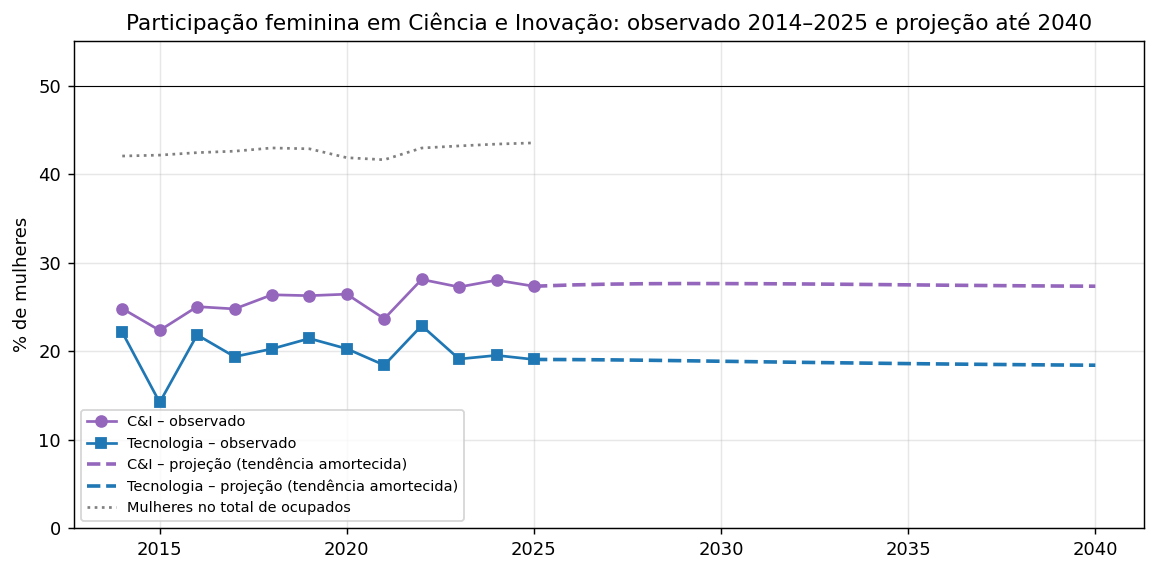

In [ ]:
# ---------- Quando chega a paridade? Extrapolação linear simples da % de mulheres (2014–2025, sem pandemia) ----------
def anos_ate_paridade(serie_pct):
    s = serie_pct.drop(index=[2020, 2021], errors='ignore')
    a, b = np.polyfit(s.index.values, s.values, 1)
    ano_50 = (50 - b) / a if a > 0 else np.inf
    return a, ano_50

serie_tec = ci[ci.subarea == 'Tecnologia'].groupby('Ano').apply(lambda d: pct(d, d.mulher), include_groups=False)
for nome, s in [('C&I', serie_ci['% mulheres']), ('Tecnologia', serie_tec)]:
    a, ano_50 = anos_ate_paridade(s)
    print(f"{nome:11s}: +{a:.2f} ponto/ano  →  50% de mulheres por volta de {ano_50:.0f}")

# ---------- Gráfico ----------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(serie_ci.index, serie_ci['% mulheres'], 'o-', color='tab:purple', label='C&I – observado')
ax.plot(serie_tec.index, serie_tec.values, 's-', color='tab:blue', label='Tecnologia – observado')
for grupo, cor in [('C&I', 'tab:purple'), ('Tecnologia', 'tab:blue')]:
    t = resumo_gen[(resumo_gen.grupo == grupo) & (resumo_gen.regime == 'Tendência amortecida')]
    ax.plot(t.ano, t['% mulheres'], '--', color=cor, lw=2, label=f'{grupo} – projeção (tendência amortecida)')
ax.plot(serie_ci.index, serie_ci['% mulheres – todos os ocupados'], ':', color='gray',
        label='Mulheres no total de ocupados')
ax.axhline(50, color='black', lw=0.6)
ax.set_ylim(0, 55); ax.set_ylabel('% de mulheres'); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title('Participação feminina em Ciência e Inovação: observado 2014–2025 e projeção até 2040')
plt.tight_layout(); plt.show()

### Revisão setorial (V4013): o que já foi feito e o que falta

A auditoria que já existe no notebook de clusters (células 83–85) olhou seis casos de fronteira escolhidos à mão: veterinários, engenheiros civis, agrônomos, técnicos de TIC, economistas e motoristas. Ela resolveu todos sem precisar de regras condicionais.

O que o relatório pede agora é estender a auditoria a todas as famílias, de forma sistemática, para encontrar casos de fronteira que ninguém escolheu olhar.

A ideia: um índice de "alinhamento setorial"

Para cada família, a pergunta é: que parte dos seus trabalhadores está em setores que combinam com a âncora onde ela foi colocada?

Para isso, a célula monta um mapa de afinidade entre as divisões da CNAE (os 2 primeiros dígitos da V4013) e as âncoras. Por exemplo:

divisões 01–03 (agropecuária) → Agropecuária e Pesca;
49–53 (transporte) → Transporte e Logística;
86 (saúde) → Saúde e Cuidados;
85 (educação) → Educação;
97 (serviços domésticos) → Cuidados.

Uma família com alinhamento baixo pode estar na âncora errada, ou pode ser uma ocupação que trabalha em muitos setores.

Duas âncoras ficam fora do alerta, por construção: Administração e Gestão e Segurança e Defesa. São ocupações transversais: toda empresa tem RH, contabilidade e vigilância. A auditoria anterior já concluiu isso, e o índice baixo delas não indica erro.

Base: 2023–2025 agrupados, para ter amostra suficiente por família.

In [ ]:
#INdice de alinhamento
# Recarrega se o Colab tiver reiniciado
if 'ocup' not in globals():
    ocup = pd.read_parquet(pasta + 'checkpoint_base_v2.parquet')
    ocup['Ano'] = ocup['Ano'].astype(int)
    ocup['V4010'] = ocup['V4010'].astype(str).str.zfill(4)
if 'cw' not in globals():
    cw = pd.read_csv(pasta + 'familias_COD_ancoras_final.csv', sep=';', dtype={'cod_familia': str})
    cw['cod_familia'] = cw['cod_familia'].str.zfill(4)

# ---------- Mapa: divisão CNAE-Domiciliar (2 dígitos) → âncora(s) de afinidade natural ----------
def ancoras_do_setor(div):
    d = int(div) if str(div).isdigit() else -1
    if 1 <= d <= 3:    return {'Agropecuária e Pesca'}
    if 5 <= d <= 43:   return {'Indústria, Produção e Infraestrutura'}      # extrativa, transformação, utilidades, construção
    if d == 45:        return {'Comércio, Serviços e Lazer', 'Indústria, Produção e Infraestrutura'}  # comércio e reparação de veículos
    if 46 <= d <= 48:  return {'Comércio, Serviços e Lazer'}                # comércio (na CNAE-Dom, 48)
    if 49 <= d <= 53:  return {'Transporte e Logística'}
    if 55 <= d <= 56:  return {'Comércio, Serviços e Lazer'}                # alojamento e alimentação
    if 58 <= d <= 60:  return {'Humanidades e Cultura'}                     # edição, audiovisual, rádio e TV
    if 61 <= d <= 63:  return {'Ciência e Inovação'}                        # telecom e TI
    if 64 <= d <= 70:  return {'Administração e Gestão'}                    # finanças, imobiliárias, jurídico, contábil, consultoria
    if 71 <= d <= 72:  return {'Ciência e Inovação'}                        # engenharia, P&D
    if 73 <= d <= 74:  return {'Humanidades e Cultura'}                     # publicidade, design
    if d == 75:        return {'Comércio, Serviços e Lazer'}                # veterinária (decisão do crosswalk)
    if d in (77, 78, 82): return {'Administração e Gestão'}                 # aluguéis, RH terceirizado, apoio administrativo
    if d == 79:        return {'Comércio, Serviços e Lazer'}                # agências de viagem e turismo
    if d == 80:        return {'Segurança e Defesa'}                        # vigilância e segurança privada
    if d == 81:        return {'Comércio, Serviços e Lazer'}                # limpeza e conservação de edifícios
    if d == 84:        return {'Administração e Gestão', 'Segurança e Defesa'}
    if d == 85:        return {'Educação'}
    if d == 86:        return {'Saúde', 'Cuidados'}
    if 87 <= d <= 88:  return {'Cuidados'}                                  # assistência social, residencial
    if 90 <= d <= 93:  return {'Humanidades e Cultura', 'Comércio, Serviços e Lazer'}
    if 94 <= d <= 96:  return {'Comércio, Serviços e Lazer'}
    if d == 97:        return {'Cuidados'}                                  # serviços domésticos
    return set()

TRANSVERSAIS = {'Administração e Gestão', 'Segurança e Defesa'}   # "overhead" da economia, por construção

# ---------- Base: 2023–2025 agrupados (amostra suficiente por família) ----------
aud_base = ocup[(ocup.Ano >= 2023) & ocup.ancora.notna() & ~ocup.ancora.astype(str).str.contains('carve', na=False)].copy()
aud_base['div'] = aud_base.V4013.astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(5).str[:2]
aud_base['alinhado'] = [a in ancoras_do_setor(d) for a, d in zip(aud_base.ancora, aud_base['div'])]

def auditoria(g):
    massa = g.groupby('div')['V1032'].sum().sort_values(ascending=False)
    return pd.Series({
        'n (2023–25)':        len(g),
        'ocupados (mil/ano)': g.V1032.sum() / 3 / 1e3,
        '% alinhado à âncora': 100 * g.V1032[g.alinhado].sum() / g.V1032.sum(),
        'setor dominante':     massa.index[0],
        '% no dominante':      100 * massa.iloc[0] / massa.sum(),
        '2º setor':            massa.index[1] if len(massa) > 1 else '',
        '% no 2º':             100 * massa.iloc[1] / massa.sum() if len(massa) > 1 else 0,
    })

aud_fam = (aud_base.groupby(['ancora', 'nivel', 'V4010'])
                   .apply(auditoria, include_groups=False).reset_index())
aud_fam = aud_fam.merge(cw[['cod_familia', 'nome_familia']], left_on='V4010', right_on='cod_familia', how='left')
aud_fam['transversal'] = aud_fam.ancora.isin(TRANSVERSAIS)

# ---------- Visão por âncora: quanto da âncora trabalha em setores "seus"? ----------
resumo_anc = (aud_base.groupby('ancora')
              .apply(lambda g: 100 * g.V1032[g.alinhado].sum() / g.V1032.sum(), include_groups=False)
              .rename('% alinhado').sort_values())
print("=== % dos ocupados de cada âncora em setores de afinidade natural (2023–25) ===")
display(resumo_anc.round(1).to_frame())

=== % dos ocupados de cada âncora em setores de afinidade natural (2023–25) ===


,% alinhado
ancora,
Administração e Gestão,43.3
Ciência e Inovação,45.7
Humanidades e Cultura,61.0
Transporte e Logística,62.3
Saúde,68.6
Segurança e Defesa,70.9
"Comércio, Serviços e Lazer",74.5
Cuidados,78.0
"Indústria, Produção e Infraestrutura",82.1


In [ ]:
# ---------- Candidatas à revisão: baixo alinhamento, amostra suficiente, âncora não transversal ----------
pd.set_option('display.max_rows', 200)
LIMIAR_ALINH, N_MIN = 30, 100

candidatas = (aud_fam[(~aud_fam.transversal) &
                      (aud_fam['% alinhado à âncora'] < LIMIAR_ALINH) &
                      (aud_fam['n (2023–25)'] >= N_MIN)]
              .sort_values('ocupados (mil/ano)', ascending=False))

cols = ['ancora', 'nivel', 'V4010', 'nome_familia', 'n (2023–25)', 'ocupados (mil/ano)',
        '% alinhado à âncora', 'setor dominante', '% no dominante', '2º setor', '% no 2º']
print(f"Famílias candidatas à revisão: {len(candidatas)} "
      f"(de {(~aud_fam.transversal & (aud_fam['n (2023–25)'] >= N_MIN)).sum()} com amostra suficiente)")
display(candidatas[cols].round(1))

aud_fam.to_excel(pasta + 'auditoria_setorial_V4013.xlsx', index=False)
print("✓ auditoria completa salva em auditoria_setorial_V4013.xlsx")

Famílias candidatas à revisão: 48 (de 264 com amostra suficiente)


,ancora,nivel,V4010,nome_familia,n (2023–25),ocupados (mil/ano),% alinhado à âncora,setor dominante,% no dominante,2º setor,% no 2º
223,Cuidados,Especialista,2342,Professores do ensino pré-escolar,4121,799.9,0.0,85,100.0,,0.0
169,"Comércio, Serviços e Lazer",Básico/Operacional,8153,Operadores de máquinas de costura,3674,761.9,2.0,14,87.0,15,5.3
210,Cuidados,Básico/Operacional,5312,Ajudantes de professores,2517,483.8,0.0,85,100.0,,0.0
162,"Comércio, Serviços e Lazer",Básico/Operacional,7531,"Alfaiates, modistas, chapeleiros e peleteiros",2430,465.9,1.9,14,95.6,13,1.4
201,"Comércio, Serviços e Lazer",Técnico,3334,Agentes imobiliários,1725,383.3,0.0,68,98.6,69,0.8
415,Transporte e Logística,Básico/Operacional,8344,Operadores de empilhadeiras,1231,303.0,15.7,48,18.8,10,10.8
305,"Indústria, Produção e Infraestrutura",Básico/Operacional,7422,Instaladores e reparadores em tecnologias da i...,1307,298.0,7.4,95,49.6,61,28.6
369,"Indústria, Produção e Infraestrutura",Técnico,3513,Técnicos de redes e sistemas de computadores,1147,273.2,11.4,62,41.4,61,14.2
153,"Comércio, Serviços e Lazer",Básico/Operacional,7318,"Artesãos de tecidos, couros e materiais semelh...",1312,234.8,2.7,13,81.3,15,12.3
182,"Comércio, Serviços e Lazer",Básico/Operacional,9611,Coletores de lixo e material reciclável,1295,230.9,16.5,84,47.4,38,30.7


✓ auditoria completa salva em auditoria_setorial_V4013.xlsx


In [ ]:
q = sintese.copy()
q.loc['TOTAL'] = q.sum()
print("=== Cenários de política, ocupados em 2040 (milhões) ===")
display(q.round(3))

o25 = ocup[ocup.Ano == 2025]
frac_pub = (o25[o25.setor_publico.astype(str).str.startswith('Púb')].groupby('ancora')['V1032'].sum()
            / o25.groupby('ancora')['V1032'].sum()).fillna(0)
frac_niv = (o25.groupby(['ancora', 'nivel'])['V1032'].sum()
            / o25.groupby('ancora')['V1032'].sum())
print("\nFração no setor público (2025), por âncora:"); print(frac_pub.round(3))
print("\nAdministração e Gestão – fração Básico/Operacional:",
      round(frac_niv.get(('Administração e Gestão', 'Básico/Operacional'), 0), 3))

=== Cenários de política, ocupados em 2040 (milhões) ===


cenário de política,base,IA_moderado,IA_forte,PNC_moderado,PNC_forte,Fiscal_moderado,Fiscal_forte,combinado_mod
ancora,,,,,,,,
Administração e Gestão,15.361,14.135,12.910,15.361,15.361,15.126,14.892,13.920
Agropecuária e Pesca,7.235,7.235,7.235,7.235,7.235,7.235,7.235,7.235
Ciência e Inovação,2.528,2.528,2.528,2.528,2.528,2.528,2.528,2.528
"Comércio, Serviços e Lazer",33.661,33.156,32.651,33.661,33.661,33.661,33.661,33.156
Cuidados,11.744,11.744,11.744,12.918,14.093,11.516,11.289,12.668
Educação,3.781,3.781,3.781,3.781,3.781,3.594,3.407,3.594
Humanidades e Cultura,1.476,1.409,1.343,1.476,1.476,1.476,1.476,1.409
"Indústria, Produção e Infraestrutura",18.550,18.550,18.550,18.550,18.550,18.550,18.550,18.550
Saúde,2.741,2.741,2.741,2.741,2.741,2.686,2.632,2.686



Fração no setor público (2025), por âncora:
ancora
Administração e Gestão                  0.204
Agropecuária e Pesca                    0.004
Ciência e Inovação                      0.104
Comércio, Serviços e Lazer              0.038
Cuidados                                0.258
Educação                                0.659
Humanidades e Cultura                   0.064
Indústria, Produção e Infraestrutura    0.021
Saúde                                   0.267
Segurança e Defesa                      0.502
Transporte e Logística                  0.051
carve-out, sem projeção                 1.000
Name: V1032, dtype: float64

Administração e Gestão – fração Básico/Operacional: 0.532


## O cenário de escolarização juvenil
O cenário de escolarização juvenil

"sem esse refinamento, o modelo corre o risco de tratar como puramente demográfica uma dinâmica que é, em parte, de política educacional".

O problema, em uma frase

A camada 1 congela a taxa de ocupação dos jovens de 2025. Isso embute como permanente, por exemplo, que parte dos jovens de 15–17 anos trabalha em vez de estudar, ou que uma fração de 18–24 não estuda nem trabalha. Mas essas proporções são resultado de política educacional, e podem mudar.

Como montar o cenário

A ideia é separar os jovens de 14 a 24 anos em quatro situações, e não só em "ocupado" e "não ocupado":

Situação	O que significa para a projeção
Só estuda	fora do mercado agora, mas entra mais tarde e mais escolarizado
Estuda e trabalha	ocupado, geralmente em tempo parcial e em nível Básico
Só trabalha	ocupado, muitas vezes com evasão escolar precoce
Nem estuda nem trabalha	fora dos dois; o grupo que a política mais quer reduzir

Com isso, dá para desenhar cenários concretos:

Base: as proporções de 2025 ficam congeladas. É o que o modelo faz hoje, implicitamente.
Permanência ampliada: metas de política educacional se cumprem. Mais jovens de 15–17 anos só estudando, menos "nem-nem" em 18–24. Efeito: a ocupação juvenil cai no curto prazo, mas essas coortes entram depois, mais escolarizadas, em níveis mais altos (Técnico, Especialista).
Retração ou represamento: a evasão e os "nem-nem" aumentam. Efeito: entrada precoce e informal no nível Básico.


Os dados da juventude dizem que os dois grupos etários estão em situações muito diferentes, e isso orienta o desenho dos cenários.

14 a 17 anos: melhora forte e contínua
14–17 anos	2014	2019	2025
Só estuda	74,7%	81,0%	83,2%
Estuda e trabalha	12,6%	9,7%	10,3%
Só trabalha	4,4%	2,4%	2,0%
Nem estuda nem trabalha	8,2%	6,9%	4,6%
Frequenta escola (total)	87,3%	90,7%	93,5%

A frequência escolar subiu de 87% para 94%, e os que estão fora da escola (só trabalham ou nem-nem) caíram pela metade, de 12,6% para 6,6%. Já estamos perto da universalização, que era a meta 3 do PNE de 2014 (Lei 13.005/2014) para os 15–17 anos. A margem restante é de ~6,6 pontos: uns 400 mil jovens.

18 a 24 anos: estagnação na escola, e o nem-nem só caiu com o mercado de trabalho
18–24 anos	2014	2019	2020	2025
Só estuda	16,1%	17,1%	20,6%	15,2%
Estuda e trabalha	14,4%	14,0%	12,0%	16,3%
Só trabalha	44,2%	39,5%	33,3%	44,9%
Nem estuda nem trabalha	25,4%	29,4%	34,1%	23,6%
Frequenta escola	30,5%	31,1%	32,6%	31,5%
A frequência escolar dos 18–24 anos não saiu do lugar em 11 anos: cerca de 31%.
O nem-nem subiu com a crise (de 25% em 2014 para 30% em 2016–19 e 34% em 2020) e caiu com a recuperação do emprego, para 24% em 2025. A queda veio pela via do trabalho, não da escola.
Três quartos dos nem-nem estão fora da força de trabalho: 3,7 milhões não procuram emprego, contra 1,3 milhão de desocupados em 2025. Os desocupados caíram de 3,1 milhões (2020) para 1,3 milhão, e os que estão fora da força ficaram praticamente parados (~3,7–4,2 milhões). Esse é o núcleo duro, e não se resolve só com crescimento econômico.

Para o texto: "A política educacional brasileira praticamente universalizou a escolarização dos 14–17 anos, mas não alterou a trajetória dos 18–24: sua frequência escolar permanece em torno de 31% desde 2014. A redução recente dos jovens que não estudam nem trabalham deveu-se à recuperação do emprego, e não à escola; o núcleo de cerca de 3,7 milhões fora da força de trabalho mostrou-se insensível ao ciclo."

Os cenários, agora com parâmetros ancorados nos dados

Um ponto importante para o avaliador: tirar um jovem do nem-nem não reduz necessariamente a ocupação. Depende de para onde ele vai: se vai para "só estuda", a ocupação não muda; se vai para "estuda e trabalha", ela aumenta. Por isso cada cenário precisa dizer para onde vão os jovens.

Cenário (meta em 2040, rampa linear a partir de 2027)	14–17 anos	18–24 anos
Base	distribuição de 2025 congelada (equivale à camada 1)	idem
Permanência ampliada	universalização: só trabalha → 0; nem-nem → 2%. Os dois vão para "só estuda"	nem-nem 23,6% → 15% (metade para "só estuda", metade para "estuda e trabalha"); só trabalha 44,9% → 40% (vão para "estuda e trabalha")
Retração	volta à média de 2016–19, o período recente mais desfavorável	volta à média de 2016–19 (nem-nem ~30%)

In [ ]:
# Preparação (caso o Colab tenha reiniciado)
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, numpy as np
pasta = '/content/drive/MyDrive/Colab Notebooks/'

jov = pd.read_parquet(pasta + 'pnadc_jovens_14a24_2014_2025.parquet')
for c in ['Ano', 'V2009', 'V1032', 'V3002', 'VD4001', 'VD4002', 'VD3004', 'V2007']:
    jov[c] = pd.to_numeric(jov[c], errors='coerce')
jov['Ano'] = jov['Ano'].astype(int)

# ---------- As quatro situações ----------
estuda   = jov.V3002 == 1            # frequenta escola/curso (1 = sim)
trabalha = jov.VD4002 == 1           # ocupado
jov['situacao'] = np.select(
    [estuda & ~trabalha, estuda & trabalha, ~estuda & trabalha, ~estuda & ~trabalha],
    ['Só estuda', 'Estuda e trabalha', 'Só trabalha', 'Nem estuda nem trabalha'], default='?')
# nem-nem: desocupado (procura trabalho) × fora da força de trabalho
jov['nemnem_tipo'] = np.where(jov.situacao != 'Nem estuda nem trabalha', None,
                              np.where(jov.VD4002 == 2, 'nem-nem desocupado', 'nem-nem fora da força'))
jov['faixa'] = pd.cut(jov.V2009, bins=[13, 17, 24], labels=['14–17', '18–24'])

print("Conferência – registros por ano e sem V3002:")
display(jov.groupby('Ano').agg(n=('V1032', 'size'), sem_V3002=('V3002', lambda s: s.isna().sum())).T)

# ---------- Série 2014–2025: distribuição (%) por faixa ----------
ORDEM = ['Só estuda', 'Estuda e trabalha', 'Só trabalha', 'Nem estuda nem trabalha']
dist = (jov.groupby(['faixa', 'Ano', 'situacao'], observed=True)['V1032'].sum()
           .groupby(level=['faixa', 'Ano']).transform(lambda s: 100 * s / s.sum())
           .unstack('situacao')[ORDEM])
for f in ['14–17', '18–24']:
    print(f"\n=== {f} anos: distribuição (%) ===")
    display(dist.loc[f].round(1).T)

# ---------- Nem-nem: desocupados × fora da força ----------
nn = (jov[jov.situacao == 'Nem estuda nem trabalha']
        .groupby(['faixa', 'Ano', 'nemnem_tipo'], observed=True)['V1032'].sum()
        .unstack('nemnem_tipo') / 1e3)
print("\n=== Nem-nem (mil pessoas) ===")
display(nn.round(0).unstack('faixa'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Conferência – registros por ano e sem V3002:


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
n,86354,84506,83690,82503,79238,76282,58519,54313,60312,59988,58210,60182
sem_V3002,0,0,0,0,0,0,0,0,0,0,0,0



=== 14–17 anos: distribuição (%) ===


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
situacao,,,,,,,,,,,,
Só estuda,74.7,75.8,80.0,80.0,80.5,81.0,86.0,86.9,81.3,83.0,83.3,83.2
Estuda e trabalha,12.6,12.6,9.3,9.5,9.7,9.7,6.9,7.6,11.5,10.2,10.7,10.3
Só trabalha,4.4,3.6,2.7,2.9,2.4,2.4,1.3,1.0,2.2,2.2,1.9,2.0
Nem estuda nem trabalha,8.2,8.0,8.0,7.6,7.3,6.9,5.8,4.6,4.9,4.6,4.1,4.6



=== 18–24 anos: distribuição (%) ===


Ano,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
situacao,,,,,,,,,,,,
Só estuda,16.1,16.0,17.5,17.5,17.7,17.1,20.6,20.3,15.8,15.0,15.1,15.2
Estuda e trabalha,14.4,14.1,13.2,13.6,13.6,14.0,12.0,13.3,14.3,14.8,15.0,16.3
Só trabalha,44.2,42.3,38.8,38.7,38.2,39.5,33.3,35.3,43.4,44.1,45.7,44.9
Nem estuda nem trabalha,25.4,27.6,30.5,30.2,30.5,29.4,34.1,31.1,26.5,26.1,24.2,23.6



=== Nem-nem (mil pessoas) ===


nemnem_tipo nem-nem desocupado         nem-nem fora da força        
faixa                    14–17   18–24                 14–17   18–24
Ano                                                                 
2014                     158.0  1756.0                 979.0  4204.0
2015                     182.0  2267.0                 904.0  4236.0
2016                     212.0  2926.0                 862.0  4229.0
2017                     190.0  3067.0                 805.0  4052.0
2018                     200.0  2978.0                 735.0  4178.0
2019                     165.0  2922.0                 698.0  3951.0
2020                     143.0  3106.0                 590.0  4737.0
2021                      85.0  3078.0                 481.0  3980.0
2022                      93.0  2068.0                 506.0  3888.0
2023                      81.0  1783.0                 471.0  3990.0
2024                      68.0  1491.0                 420.0  3740.0
2025                      54.0  1340.0                 481.0  3715.0

### Vamos projetar os cenários

In [ ]:
pop_longo = pd.read_parquet(pasta + 'projecoes_ibge_longo.parquet')
pop_longo['idade'] = pop_longo['idade'].astype(str).str.replace('+', '', regex=False).astype(int)
pop_j = (pop_longo[pop_longo.idade.between(14, 24)]
         .assign(faixa=lambda d: np.where(d.idade <= 17, '14–17', '18–24'))
         .groupby(['ano', 'faixa'])['populacao'].sum().unstack())

base25 = dist.xs(2025, level='Ano')                                   # % em 2025
ruim   = dist[dist.index.get_level_values('Ano').isin([2016, 2017, 2018, 2019])] \
             .groupby(level='faixa', observed=True).mean()            # média 2016–19

alvo = {
  'Base': base25,
  'Permanência ampliada': pd.DataFrame({
      'Só estuda':               {'14–17': 100 - base25.loc['14–17', 'Estuda e trabalha'] - 2.0, '18–24': base25.loc['18–24', 'Só estuda'] + 4.3},
      'Estuda e trabalha':       {'14–17': base25.loc['14–17', 'Estuda e trabalha'],
                                  '18–24': base25.loc['18–24', 'Estuda e trabalha'] + 4.3 + (base25.loc['18–24', 'Só trabalha'] - 40.0)},
      'Só trabalha':             {'14–17': 0.0,  '18–24': 40.0},
      'Nem estuda nem trabalha': {'14–17': 2.0,  '18–24': 15.0}})[ORDEM],
  'Retração': ruim[ORDEM],
}
print("Metas de 2040 (%):"); display(pd.concat(alvo).round(1))

def rampa(ano, ini=2027, fim=2040):
    return float(np.clip((ano - ini + 1) / (fim - ini + 1), 0, 1))

linhas = []
for cen, meta in alvo.items():
    for ano in range(2025, 2041):
        for f in ['14–17', '18–24']:
            s = base25.loc[f] + rampa(ano) * (meta.loc[f] - base25.loc[f])   # % no ano
            n = s / 100 * pop_j.loc[ano, f] / 1e3                             # mil pessoas
            linhas.append({'cenário': cen, 'ano': ano, 'faixa': f,
                           'população': pop_j.loc[ano, f] / 1e3,
                           'estudando': n['Só estuda'] + n['Estuda e trabalha'],
                           'ocupados':  n['Estuda e trabalha'] + n['Só trabalha'],
                           'nem-nem':   n['Nem estuda nem trabalha']})
proj_j = pd.DataFrame(linhas)

r40 = proj_j[proj_j.ano == 2040].groupby(['cenário', 'faixa'])[['população', 'estudando', 'ocupados', 'nem-nem']].sum()
for c in ['estudando', 'ocupados', 'nem-nem']:
    r40[f'Δ {c} vs base'] = r40[c] - r40.xs('Base', level='cenário').reindex(r40.index, level='faixa')[c].values
print("\n=== 2040 (mil pessoas) ===")
display(r40.round(0))
print("\n=== 2025 (ponto de partida, mil pessoas) ===")
display(proj_j[(proj_j.ano == 2025) & (proj_j['cenário'] == 'Base')].set_index('faixa')[['população', 'estudando', 'ocupados', 'nem-nem']].round(0))

Metas de 2040 (%):


Só estuda  Estuda e trabalha  Só trabalha  \
                     faixa                                              
Base                 14–17       83.2               10.3          2.0   
                     18–24       15.2               16.3         44.9   
Permanência ampliada 14–17       87.7               10.3          0.0   
                     18–24       19.5               25.5         40.0   
Retração             14–17       80.4                9.6          2.6   
                     18–24       17.5               13.6         38.8   

                            Nem estuda nem trabalha  
                     faixa                           
Base                 14–17                      4.6  
                     18–24                     23.6  
Permanência ampliada 14–17                      2.0  
                     18–24                     15.0  
Retração             14–17                      7.5  
                     18–24                     30.1


=== 2040 (mil pessoas) ===


população  estudando  ocupados  nem-nem  \
cenário              faixa                                            
Base                 14–17     9758.0     9122.0    1193.0    446.0   
                     18–24    19432.0     6128.0   11890.0   4582.0   
Permanência ampliada 14–17     9758.0     9563.0    1002.0    195.0   
                     18–24    19432.0     8748.0   12725.0   2915.0   
Retração             14–17     9758.0     8778.0    1186.0    728.0   
                     18–24    19432.0     6038.0   10182.0   5854.0   

                            Δ estudando vs base  Δ ocupados vs base  \
cenário              faixa                                            
Base                 14–17                  0.0                 0.0   
                     18–24                  0.0                 0.0   
Permanência ampliada 14–17                441.0              -191.0   
                     18–24               2620.0               836.0   
Retração             14–17               -344.0                -7.0   
                     18–24                -90.0             -1708.0   

                            Δ nem-nem vs base  
cenário              faixa                     
Base                 14–17                0.0  
                     18–24                0.0  
Permanência ampliada 14–17             -251.0  
                     18–24            -1667.0  
Retração             14–17              282.0  
                     18–24             1272.0


=== 2025 (ponto de partida, mil pessoas) ===


,população,estudando,ocupados,nem-nem
faixa,,,,
14–17,11647.0,10888.0,1424.0,532.0
18–24,21611.0,6815.0,13222.0,5096.0
